In [2]:
!pip install python-docx pandas matplotlib scipy scikit-learn umap-learn torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 5.1 MB/s eta 0:00:00


In [6]:
from docx import Document

import pandas as pd
import numpy as np

from google.colab import drive

import os
import re

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy import stats
from scipy.stats import mannwhitneyu, kruskal
from scipy.spatial.distance import pdist, squareform

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
# UMAP (Uniform Manifold Approximation and Projection - non-linear
#dimensionality reduction. Durán et al. (2021) showed that linear methods
#can miss structure in gastric microbiome data. non-linear embeddings (UMAP,
#MCE) often reveal group separation that linear methods cannot.

import warnings
warnings.filterwarnings("ignore")

In [7]:
#Functions

#preanalisis
def df_word(word):
  lines = [p.text.strip() for p in word.paragraphs if p.text.strip() != ""]
  rows = [re.split(r'\t+', line) for line in lines]
  df = pd.DataFrame(rows[2:], columns=rows[1])
  return df

def normalize_sample_id(sample):
  #isaplha() checks for alphabetic letters
  #this code is very specific for the name of our samples
    if len(sample) == 8 and sample[-1].isalpha():
        return sample[:4] + '-' + sample[4:-1] + '-' + sample[-1]
    else:
        return sample[:4] + '-' + sample[4:]

In [8]:
#For plots

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 130, 'axes.titlesize': 11,
                     'axes.labelsize': 10, 'font.size': 9})

BINARY_COLORS = {
    'H.p.-': '#4878d0',   # blue
    'H.p.+': '#d65f5f',   # red - H. pylori positive (any CagA status)
}
BINARY_ORDER = ['H.p.-', 'H.p.+']
# ORDER defines the integer encoding:  0 = H.p.-,  1 = H.p.+

# CagA sub-palette kept for supplementary visualisations
CAGA_COLORS = {
    'H.p.-':        '#4878d0',
    'H.p.+/CagA-':  '#ee854a',
    'H.p.+/CagA+':  '#d65f5f',
}

In [9]:
#Obtaining the data
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [10]:
BASE_PATH = '/content/drive/MyDrive/semestres/segundo-semestre/redes_neuronales/proyecto/data'
sra_run_table = pd.read_csv(f'{BASE_PATH}/SraRunTable.csv')
srr_acc_list = pd.read_csv(f'{BASE_PATH}/SRR_Acc_List.txt')
t1 = Document(f'{BASE_PATH}/Table1.DOCX')
dft2 = pd.read_excel(f'{BASE_PATH}/Table2.XLSX',decimal=',')
t3 = Document(f'{BASE_PATH}/Table3.DOCX')
dft4 = pd.read_excel(f'{BASE_PATH}/Table4.XLSX',decimal=',')
dft1 = df_word(t1)
dft3 = df_word(t3)

In [11]:
sra_run_table

,Run,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,Center Name,Collection_Date,common_name,...,Platform,project_name,ReleaseDate,create_date,version,Sample Name,Sample_name,Sequencing_method,SRA Study,Submitter_Id
0,ERR2092801,AMPLICON,500,49231976,PRJEB22107,SAMEA104208451,30233935,MEDICAL UNIVERSITY GRAZ,2015,human,...,ILLUMINA,The human gastric microbiome,2018-01-26T00:00:00Z,2018-01-29T13:39:00Z,1,SAMEA104208451,MPnegCo1,pyrosequencing,ERP024440,MPnegCo1
1,ERR2092802,AMPLICON,500,10109470,PRJEB22107,SAMEA104208452,6257670,MEDICAL UNIVERSITY GRAZ,2015,human,...,ILLUMINA,The human gastric microbiome,2018-01-26T00:00:00Z,2022-07-22T15:58:00Z,2,SAMEA104208452,MPnegCo2,pyrosequencing,ERP024440,MPnegCo2
2,ERR2092803,AMPLICON,501,20604460,PRJEB22107,SAMEA104208453,12267412,MEDICAL UNIVERSITY GRAZ,2015,human,...,ILLUMINA,The human gastric microbiome,2018-01-26T00:00:00Z,2022-07-22T10:44:00Z,2,SAMEA104208453,P001Z12,pyrosequencing,ERP024440,P001Z12
3,ERR2092804,AMPLICON,501,23559583,PRJEB22107,SAMEA104208454,13914641,MEDICAL UNIVERSITY GRAZ,2015,human,...,ILLUMINA,The human gastric microbiome,2018-01-26T00:00:00Z,2022-07-18T01:32:00Z,2,SAMEA104208454,P001Z13,pyrosequencing,ERP024440,P001Z13
4,ERR2092805,AMPLICON,501,12452832,PRJEB22107,SAMEA104208455,7426793,MEDICAL UNIVERSITY GRAZ,2015,human,...,ILLUMINA,The human gastric microbiome,2018-01-26T00:00:00Z,2022-07-21T13:55:00Z,2,SAMEA104208455,P001Z14,pyrosequencing,ERP024440,P001Z14
5,ERR2092806,AMPLICON,501,29376711,PRJEB22107,SAMEA104208456,17356891,MEDICAL UNIVERSITY GRAZ,2015,human,...,ILLUMINA,The human gastric microbiome,2018-01-26T00:00:00Z,2022-07-14T08:08:00Z,2,SAMEA104208456,P001Z18,pyrosequencing,ERP024440,P001Z18
6,ERR2092807,AMPLICON,500,8199351,PRJEB22107,SAMEA104208457,5123196,MEDICAL UNIVERSITY GRAZ,2015,human,...,ILLUMINA,The human gastric microbiome,2018-01-26T00:00:00Z,2022-07-19T01:14:00Z,2,SAMEA104208457,P002Z18,pyrosequencing,ERP024440,P002Z18
7,ERR2092808,AMPLICON,501,8778617,PRJEB22107,SAMEA104208458,5273647,MEDICAL UNIVERSITY GRAZ,2015,human,...,ILLUMINA,The human gastric microbiome,2018-01-26T00:00:00Z,2022-07-19T01:14:00Z,2,SAMEA104208458,P003Z10,pyrosequencing,ERP024440,P003Z10
8,ERR2092809,AMPLICON,500,32818855,PRJEB22107,SAMEA104208459,19769896,MEDICAL UNIVERSITY GRAZ,2015,human,...,ILLUMINA,The human gastric microbiome,2018-01-26T00:00:00Z,2022-07-17T05:57:00Z,2,SAMEA104208459,P003Z15,pyrosequencing,ERP024440,P003Z15
9,ERR2092810,AMPLICON,500,12283542,PRJEB22107,SAMEA104208460,7687177,MEDICAL UNIVERSITY GRAZ,2015,human,...,ILLUMINA,The human gastric microbiome,2018-01-26T00:00:00Z,2022-07-18T01:17:00Z,2,SAMEA104208460,P004Z10-WH,pyrosequencing,ERP024440,P004Z10-WH


In [12]:
dft1

,level,taxon,comparison,mean1,mean2,pvalue,adj.pvalue,sig
0,Phylum,Actinobacteria,Hp- vs. Hp+/CagA-,0.1060,0.0332,0.0050,0.0094,**
1,Phylum,Actinobacteria,Hp- vs. Hp+/CagA+,0.1060,0.0113,0.0002,0.0006,***
2,Phylum,Actinobacteria,Hp+/CagA- vs. Hp+/CagA+,0.0332,0.0113,0.2293,0.2866,None
3,Phylum,Bacteroidetes,Hp- vs. Hp+/CagA-,0.2919,0.0430,0.0009,0.0019,**
4,Phylum,Bacteroidetes,Hp- vs. Hp+/CagA+,0.2919,0.0294,0.0007,0.0017,**
...,...,...,...,...,...,...,...,...
142,Genus,Streptococcus,Hp- vs. Hp+/CagA+,0.1896,0.0185,0.0014,0.0100,*
143,Genus,Streptococcus,Hp+/CagA- vs. Hp+/CagA+,0.0603,0.0185,0.1188,0.1716,None
144,Genus,Veillonella,Hp- vs. Hp+/CagA-,0.0619,0.0145,0.0015,0.0100,*
145,Genus,Veillonella,Hp- vs. Hp+/CagA+,0.0619,0.0114,0.0006,0.0081,**


In [13]:
dft2

,kingdom,phylum,class,order,family,genus,# OTUs,species,P001Z12,P001Z13,...,P008Z08,P021Z12,P022Z17,P029Z13,P045Z10A,P047Z15,P060Z15,P061Z10,P062Z14,P121Z15
0,k__Bacteria,p__Firmicutes,c__Bacilli,o__Lactobacillales,f__Streptococcaceae,g__Streptococcus,103,s__alactolyticus;s__anginosus;s__infantis;s__s...,0.190581,0.298446,...,0.017731,0.002377,0.004464,0.010444,0.031285,0.003381,0.042707,0.010215,0.001565,0.061214
1,k__Bacteria,p__Bacteroidetes,c__Bacteroidia,o__Bacteroidales,f__Prevotellaceae,g__Prevotella,86,s__copri;s__intermedia;s__melaninogenica;s__na...,0.139397,0.084351,...,0.055815,0.002485,0.011565,0.031708,0.006547,0.009166,0.026263,0.000696,0.000978,0.055244
2,k__Bacteria,p__Actinobacteria,c__Actinobacteria,o__Actinomycetales,f__Actinomycetaceae,g__Actinomyces,50,NaN,0.048744,0.087595,...,0.023244,0.000216,0.000271,0.002404,0.001413,0.000902,0.019574,0.001064,0.000391,0.014078
3,k__Bacteria,p__Proteobacteria,c__Epsilonproteobacteria,o__Campylobacterales,f__Helicobacteraceae,g__Helicobacter,38,s__pylori,0.000034,0.000463,...,0.803767,0.977492,0.964272,0.912465,0.907772,0.968595,0.784132,0.951709,0.984744,0.765660
4,k__Bacteria,p__Firmicutes,c__Clostridia,o__Clostridiales,f__Lachnospiraceae,g__,33,NaN,0.002095,0.003408,...,0.001013,0.000108,0.000000,0.000451,0.000000,0.000075,0.000061,0.000000,0.000733,0.001158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309,k__Bacteria,p__Synergistetes,c__Synergistia,o__Synergistales,f__Dethiosulfovibrionaceae,g__Pyramidobacter,1,s__piscolens,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
310,k__Bacteria,p__TM7,c__TM7-1,o__,f__,g__,1,NaN,0.000000,0.000218,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
311,k__Bacteria,p__TM7,c__TM7-3,Other,Other,Other,1,NaN,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
312,k__Bacteria,p__Tenericutes,c__Mollicutes,o__Acholeplasmatales,f__Acholeplasmataceae,g__,1,NaN,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [14]:
dft3

,Type,Comparison,Effect,SD,N
0,chao1,H.p.- vs. H.p.+/CagA-,43.549,89.046,67
1,chao1,H.p.- vs. H.p.+/CagA+,63.735,48.454,11
2,chao1,H.p.+/CagA- vs. H.p.+/CagA+,20.186,89.046,307
3,observed_species,H.p.- vs. H.p.+/CagA-,55.633,72.593,28
4,observed_species,H.p.- vs. H.p.+/CagA+,73.633,49.376,9
5,observed_species,H.p.+/CagA- vs. H.p.+/CagA+,18.000,72.593,257
6,PD_whole_tree,H.p.- vs. H.p.+/CagA-,2.898,3.080,19
7,PD_whole_tree,H.p.- vs. H.p.+/CagA+,2.982,1.986,9
8,PD_whole_tree,H.p.+/CagA- vs. H.p.+/CagA+,0.084,3.080,21162


In [15]:
dft4

,ID,Taxon,P001Z12,P001Z13,P001Z14,P001Z18,P002Z18,P003Z10,P004Z17,P005Z08WH2,...,P021Z12,P022Z17,P029Z13,P045Z10A,P047Z15,P060Z15,P061Z10,P062Z14,P121Z15,Summe
0,232.0,k__Bacteria;p__Proteobacteria;c__Betaproteobac...,0.000996,0.000191,0.000289,0.000222,0.014049,0.000366,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0.000556
1,239.0,k__Bacteria;p__Proteobacteria;c__Betaproteobac...,0.001134,0.000000,0.000520,0.000533,0.012391,0.000586,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0.000523
2,218.0,k__Bacteria;p__Proteobacteria;c__Betaproteobac...,0.001099,0.000055,0.000520,0.000000,0.012129,0.000440,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0.000491
3,255.0,k__Bacteria;p__Proteobacteria;c__Deltaproteoba...,0.000000,0.000000,0.000000,0.000000,0.013351,0.000000,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0.000460
4,235.0,k__Bacteria;p__Proteobacteria;c__Betaproteobac...,0.000962,0.000109,0.001560,0.000244,0.008639,0.000879,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0.000427
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,253.0,k__Bacteria;p__Proteobacteria;c__Deltaproteoba...,0.000000,0.000055,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0.000002
62,254.0,k__Bacteria;p__Proteobacteria;c__Deltaproteoba...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000051,0.000000,...,0,0,0,0,0,0,0,0,0,0.000002
63,87.0,k__Bacteria;p__Firmicutes;c__Bacilli;Other;Oth...,0.000000,0.000000,0.000000,0.000044,0.000000,0.000000,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0.000002
64,302.0,k__Bacteria;p__Spirochaetes;c__[Leptospirae];o...,0.000000,0.000000,0.000000,0.000044,0.000000,0.000000,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0.000002


In [16]:
data = {
    "Sample_ID": [
        "P005-Z08","P002-Z18","P003-Z10","P001-Z14","P004-Z10e",
        "P001-Z12","P007-Z08","P001-Z13","P004-Z17","P001-Z18",
        "P052-Z10","P107-Z15","P033-Z12","P008-Z17","P058-Z14",
        "P080-Z15","P003-Z15","P022-Z12","P066-Z10","P022-Z13",
        "P121-Z15","P029-Z13","P047-Z15","P060-Z15","P062-Z14",
        "P021-Z12","P008-Z08","P022-Z17","P061-Z10","P045-Z10-A"
    ],
    "Reads": [
        11346,11460,13651,17305,18310,
        29111,35447,36680,39276,45063,
        15743,16451,26728,26941,27627,
        44882,48255,48502,57636,188261,
        11223,13309,13310,16297,20451,
        27768,33557,59142,73327,79271
    ],
    "Hp_CagA_Status": [
        "H.p.-","H.p.-","H.p.-","H.p.-","H.p.-",
        "H.p.-","H.p.-","H.p.-","H.p.-","H.p.-",
        "H.p.+/CagA-","H.p.+/CagA-","H.p.+/CagA-","H.p.+/CagA-","H.p.+/CagA-",
        "H.p.+/CagA-","H.p.+/CagA-","H.p.+/CagA-","H.p.+/CagA-","H.p.+/CagA-",
        "H.p.+/CagA+","H.p.+/CagA+","H.p.+/CagA+","H.p.+/CagA+","H.p.+/CagA+",
        "H.p.+/CagA+","H.p.+/CagA+","H.p.+/CagA+","H.p.+/CagA+","H.p.+/CagA+"
    ],
    "Age": [
        23,38,56,56,83,
        54,50,66,27,50,
        50,51,66,34,43,
        76,69,75,64,71,
        33,37,40,59,51,
        21,32,50,32,51
    ],
    "Sex": [
        "F","F","M","F","M",
        "M","M","M","M","M",
        "F","M","F","F","M",
        "F","F","F","M","F",
        "M","F","M","F","F",
        "F","M","M","F","M"
    ],
    "Indication": [
        "cd","rs","uap","uap","bl",
        "uap","uap","rs","uap","un",
        "un","rs","un","uap","rs",
        "uap","cu","un","bl","cu",
        "uap","rs","uap","rs","rs",
        "ibs","uap","an","ibs","bl"
    ],
    "Diagnosis": [
        "nf","g, r","g","ci","g, r, u",
        "g, r, öv","r","nf","nf","r",
        "g","g, r, he","g, r","nf","g, ci",
        "g, he","g","g, he, di","g, he","g",
        "g","nf","g, ud","g, r","ci",
        "g","g","nf","g, di, l","g"
    ],
    "Score": [
        "na","na","na","na","na",
        "na","na","na","na","na",
        "3+","2+","1+","2+","3+",
        "2+","2+","3+","2+","2+",
        "2+","3+","2+","2+","3+",
        "3+","3+","2+","3+","3+"
    ]
}
terms_indication={"an": "anemia",
                          "bl":"bleeding",
                          "cd":"celiac disease",
                          "cu":"check-up",
                          "ibs": "irritable bowel syndrome",
                          "rs":"reflux",
                          "uap":"upper abdominal pain",
                          "un":"unknown"}

terms_quiime={"na":"not aplicable",
              "e":"not included to statistical analysis"}
terms_diagnosis={"ci": "cardial insufficiency",
                 "di": "duodenal inflammation",
                 "g": "gastritis",
                 "he": "hernia",
                 "l": "lymphoedema",
                 "nf":"no finding",
                 "öv":"ösophagus varizen",
                 "r":"reflux",
                 "u":"ulcer",
                 "ud":"ulcer duodenum"}

patients_df=pd.DataFrame(data)
dfp=patients_df


dfp["Diagnosis"] = (
    dfp["Diagnosis"]
        .str.split(",")
        .apply(lambda x: [terms_diagnosis.get(i.strip(), i.strip()) for i in x])
        .str.join(", ")
)

for i in dfp:
  if i=="Indication":
     dfp['Indication']=dfp['Indication'].replace(terms_indication)
  if i=='Score':
      dfp['Score']=dfp['Score'].replace(terms_quiime)

#Según la literatura, los autores no tuvieron en cuenta al paciente
#P004-Z10 porque su condición alteraba los datos.
dfp=dfp[dfp["Sample_ID"] != "P004-Z10e"]
dfp

,Sample_ID,Reads,Hp_CagA_Status,Age,Sex,Indication,Diagnosis,Score
0,P005-Z08,11346,H.p.-,23,F,celiac disease,no finding,not aplicable
1,P002-Z18,11460,H.p.-,38,F,reflux,"gastritis, reflux",not aplicable
2,P003-Z10,13651,H.p.-,56,M,upper abdominal pain,gastritis,not aplicable
3,P001-Z14,17305,H.p.-,56,F,upper abdominal pain,cardial insufficiency,not aplicable
5,P001-Z12,29111,H.p.-,54,M,upper abdominal pain,"gastritis, reflux, ösophagus varizen",not aplicable
6,P007-Z08,35447,H.p.-,50,M,upper abdominal pain,reflux,not aplicable
7,P001-Z13,36680,H.p.-,66,M,reflux,no finding,not aplicable
8,P004-Z17,39276,H.p.-,27,M,upper abdominal pain,no finding,not aplicable
9,P001-Z18,45063,H.p.-,50,M,unknown,reflux,not aplicable
10,P052-Z10,15743,H.p.+/CagA-,50,F,unknown,gastritis,3+


In [17]:
dft4['Taxon'][0]

'k__Bacteria;p__Proteobacteria;c__Betaproteobacteria;o__Burkholderiales;f__Oxalobacteraceae;g__'

In [19]:
#Elimino helicobacter pylori porque puede sesgar el modelo al ser la especie más abundante.
#Sin embargo, en el paper de 2017 incluyen hp...
#If i keep this, i should always compare with bray curtis distances and clr transformations the full comunity, without hp not normalized and without hp renormalized.
dft2_nhp = dft2[dft2["genus"] != "g__Helicobacter"].copy()

In [20]:
dfp.info()
dft1.info()
dft2_nhp.info()
dft3.info()
dft4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29 entries, 0 to 29
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Sample_ID       29 non-null     object
 1   Reads           29 non-null     int64 
 2   Hp_CagA_Status  29 non-null     object
 3   Age             29 non-null     int64 
 4   Sex             29 non-null     object
 5   Indication      29 non-null     object
 6   Diagnosis       29 non-null     object
 7   Score           29 non-null     object
dtypes: int64(2), object(6)
memory usage: 2.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   level       147 non-null    object
 1   taxon       147 non-null    object
 2   comparison  147 non-null    object
 3   mean1       147 non-null    object
 4   mean2       147 non-null    object
 5   pvalue      147 non-null

In [21]:
dfp[["Reads", "Age", "Sex"]].groupby("Sex").mean().round(3)

,Reads,Age
Sex,,
F,39371.667,50.533
M,35531.786,47.643


In [22]:
print(dfp[dfp['Hp_CagA_Status'] == 'H.p.-'].shape[0])
print(dfp[dfp['Hp_CagA_Status'] == 'H.p.+/CagA-'].shape[0])
print(dfp[dfp['Hp_CagA_Status'] == 'H.p.+/CagA+'].shape[0])

9
10
10


In [23]:
display(dfp['Sample_ID'].head())

,Sample_ID
0,P005-Z08
1,P002-Z18
2,P003-Z10
3,P001-Z14
5,P001-Z12


Voy a explorar la segunda tabla. Tenemos 313 taxa.

In [24]:
print(f"Para un total de {dft2.shape[0]} taxones, se tienen:\n")

print(f"{dft2_nhp['phylum'].nunique()} phylum.")
print(f"{dft2_nhp['class'].nunique()} clases.")
print(f"{dft2_nhp['order'].nunique()} órdenes.")
print(f"{dft2_nhp['family'].nunique()} familias.")
print(f"{dft2_nhp['genus'].nunique()} géneros.")
print(f"{dft2_nhp['species'].nunique()} especies.")

Para un total de 314 taxones, se tienen:

19 phylum.
36 clases.
65 órdenes.
116 familias.
181 géneros.
66 especies.


In [25]:
col_s_t2=dft2.columns[8:].tolist()
col_t_t2=dft2.columns[:8].tolist()
#Cálculo de riqueza observada, que realmente es
# número de taxa con abundancia mayor a cero.
(dft2[col_s_t2] > 0).sum().sort_values(ascending=False)
#De estos datos, P001Z14 tiene alta diversidad de taxa detectados, mientras
#P062Z14 tiene poca. A mayor número, mayor complejidad microbiana.

,0
P001Z14,109
P001Z12,90
P001Z18,90
P007Z08,90
P066Z10,90
P001Z13,88
P004Z17,81
P107Z15,81
P008Z17,80
P008Z08,79


In [26]:
#Im gonna melt dft2 sample columns to merge this df with dfp

dft2_nhp_n=pd.melt(dft2_nhp, id_vars=col_t_t2, value_vars=col_s_t2,var_name='Sample_ID', value_name='Abundances')
dfp_n=dfp.copy()
dfp_n["Sample_ID"] = dfp_n["Sample_ID"].str.replace('-', '', regex=False)
patients_status = dfp_n[['Sample_ID', 'Hp_CagA_Status', 'Score']]
dfp_m= pd.merge(dft2_nhp_n,patients_status,on="Sample_ID",how='left')
#The k__ etc is a taxonomy classidier for Greengenes/QIIME.
#Dont gonna use it here so imma remove it just to make life easier.
#Other is for unresolved taxonomy.
for col in col_t_t2[:-2]:
  #r'' standard for regex
  #^ start of the string, match only if appears at the begining
  #[a-z]__ any lower case letter followed by two underscores
  #regex=True regular expression
  dfp_m[col] = dfp_m[col].str.replace(r'^[a-z]__', '', regex=True)
dfp_m=dfp_m.loc[:, ['Sample_ID', 'Hp_CagA_Status', 'Score', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', '# OTUs', 'Abundances']]
#display(dfp_m[['Sample_ID', 'Hp_CagA_Status', 'Score', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', '# OTUs', 'Abundances']])

In [27]:
dfp_m

,Sample_ID,Hp_CagA_Status,Score,kingdom,phylum,class,order,family,genus,species,# OTUs,Abundances
0,P001Z12,H.p.-,not aplicable,Bacteria,Firmicutes,Bacilli,Lactobacillales,Streptococcaceae,Streptococcus,s__alactolyticus;s__anginosus;s__infantis;s__s...,103,0.190581
1,P001Z12,H.p.-,not aplicable,Bacteria,Bacteroidetes,Bacteroidia,Bacteroidales,Prevotellaceae,Prevotella,s__copri;s__intermedia;s__melaninogenica;s__na...,86,0.139397
2,P001Z12,H.p.-,not aplicable,Bacteria,Actinobacteria,Actinobacteria,Actinomycetales,Actinomycetaceae,Actinomyces,NaN,50,0.048744
3,P001Z12,H.p.-,not aplicable,Bacteria,Firmicutes,Clostridia,Clostridiales,Lachnospiraceae,,NaN,33,0.002095
4,P001Z12,H.p.-,not aplicable,Bacteria,Firmicutes,Clostridia,Clostridiales,Veillonellaceae,Selenomonas,s__noxia,31,0.000172
...,...,...,...,...,...,...,...,...,...,...,...,...
9072,P121Z15,H.p.+/CagA+,2+,Bacteria,Synergistetes,Synergistia,Synergistales,Dethiosulfovibrionaceae,Pyramidobacter,s__piscolens,1,0.000000
9073,P121Z15,H.p.+/CagA+,2+,Bacteria,TM7,TM7-1,,,,NaN,1,0.000000
9074,P121Z15,H.p.+/CagA+,2+,Bacteria,TM7,TM7-3,Other,Other,Other,NaN,1,0.000000
9075,P121Z15,H.p.+/CagA+,2+,Bacteria,Tenericutes,Mollicutes,Acholeplasmatales,Acholeplasmataceae,,NaN,1,0.000000


In [28]:
for col in col_t_t2[:-1]:
    print(col)
    print(dft2_nhp_n[col].value_counts().head())

kingdom
kingdom
k__Bacteria    9077
Name: count, dtype: int64
phylum
phylum
p__Proteobacteria    3509
p__Firmicutes        2320
p__Actinobacteria    1247
p__Bacteroidetes      928
p__TM7                174
Name: count, dtype: int64
class
class
c__Clostridia             1392
c__Alphaproteobacteria    1160
c__Gammaproteobacteria    1102
c__Actinobacteria         1102
c__Betaproteobacteria      928
Name: count, dtype: int64
order
order
o__Clostridiales      1392
o__Actinomycetales    1102
o__Rhizobiales         551
o__Burkholderiales     522
o__Lactobacillales     464
Name: count, dtype: int64
family
family
f__                   812
Other                 464
f__Lachnospiraceae    377
f__Veillonellaceae    261
f__Micrococcaceae     203
Name: count, dtype: int64
genus
genus
g__                 2668
Other               1218
g__Streptococcus      29
g__Actinomyces        29
g__Prevotella         29
Name: count, dtype: int64
# OTUs
# OTUs
1    4060
2    1624
3    1044
4     493
5     261
Name:

Estas abundancias deben ser de ~100% por cada muestra.

In [29]:
dft2_nhp_n_rn=dft2_nhp_n.copy()
dft2_nhp_n_rn["Abundances"] = (
    dft2_nhp_n["Abundances"] /
    dft2_nhp_n.groupby("Sample_ID")["Abundances"].transform("sum")
)

In [30]:
dfp_n_n=dfp.copy()
dfp_n_n["Sample_ID"] = dfp_n["Sample_ID"].str.replace('-', '', regex=False)
patients_status = dfp_n[['Sample_ID', 'Hp_CagA_Status', 'Score']]
dfp_m_n= pd.merge(dft2_nhp_n_rn,patients_status,on="Sample_ID",how='left')
#The k__ etc is a taxonomy classidier for Greengenes/QIIME.
#Dont gonna use it here so imma remove it just to make life easier.
#Other is for unresolved taxonomy.
for col in col_t_t2[:-2]:
  #r'' standard for regex
  #^ start of the string, match only if appears at the begining
  #[a-z]__ any lower case letter followed by two underscores
  #regex=True regular expression
  dfp_m_n[col] = dfp_m_n[col].str.replace(r'^[a-z]__', '', regex=True)
dfp_m_n.groupby("Sample_ID")["Abundances"].sum()

,Abundances
Sample_ID,
P001Z12,1.0
P001Z13,1.0
P001Z14,1.0
P001Z18,1.0
P002Z18,1.0
P003Z10,1.0
P003Z15,1.0
P004Z17,1.0
P005Z08,1.0


In [ ]:
dfp_m.groupby("Sample_ID")["Abundances"].sum()

,Abundances
Sample_ID,
P001Z12,0.999382
P001Z13,0.999673
P001Z14,0.999827
P001Z18,0.999889
P002Z18,0.999127
P003Z10,1.000000
P003Z15,0.999959
P004Z17,0.999313
P005Z08,1.000000


###Análisis de datos composicionales.

A partir de `dfp_m_` vamos a construir una tabla OTU (muestras x géneros), aplicamos transformaciones CLR/rCLR y finalmente realizamos el EDA y featuring engineering.

In [31]:
#authors rarefied dft2 to 11200 reads per sample = subsampling the libraries
#to the same depth. Counts were divided by this number and those are the results
#that we see in the table.
#We need to create a constant before log bc CLR requires computing log(x) for
#every value and we need to scale it by dividing the constant/rarefraction bc
#our values are relative abundances, not raw counts. We need to use the same
#scale as our data. This constant is usually 0.5. Dividing it is mathematically
#identical to adding 0.5 counts before dividing by the library size. It
#prevents log(0) without distorting large values.

#Constants
RAREFACTION_DEPTH = 11200
PSEUDOCOUNT = 0.5 / RAREFACTION_DEPTH
print(round(PSEUDOCOUNT, 7))

4.46e-05


In [34]:
# Cleaning empty genus labels.
#Replacing empty string with 'Unclassified'.
dfp_m_n['genus'] = dfp_m_n['genus'].replace('', 'Unclassified').fillna('Unclassified')

#Pivot long-format to wide OTU table for CLR and DL.Each row is one sample,
#each column is one genus, each cell is its relative abundance in that sample.
otu = dfp_m_n.pivot_table(
    index='Sample_ID',
    columns='genus',
    values='Abundances',
    aggfunc='sum'
    # aggfunc='sum': if the same (sample, genus) pair appears in multiple
    # rows (because different species of the same genus), sum their
    # relative abundances.
).fillna(0)

#Although we are not gonna differenciate between H.p.+/CagA- and H.p.+/CagA+,
#we will keep the label for reference (it is relevant to know whether the two
#H.p.+ subgroups are clustering together or separately)
_label3_map = patients_status.set_index('Sample_ID')['Hp_CagA_Status'].to_dict()
_score_map = patients_status.set_index('Sample_ID')['Score'].to_dict()
labels_3class = otu.index.map(_label3_map)  # 'H.p.-', 'H.p.+/CagA-', 'H.p.+/CagA+'
scores = otu.index.map(_score_map)

# Create binary labels. Any sample with H. pylori present (CagA-,CagA+)->H.p.+
labels = labels_3class.map(
    lambda x: 'H.p.-' if x == 'H.p.-' else 'H.p.+'
)
# If the 3-class label is 'H.p.-' keep it; otherwise collapse to 'H.p.+'.

# Sorting the categories for the figures
_sort_val      = {'H.p.-': 0, 'H.p.+': 1}
sample_sort_key = pd.Series(labels, index=otu.index).map(_sort_val)
group_order_idx = sample_sort_key.sort_values().index

n_neg = (labels == 'H.p.-').sum()  # 9 good lord
n_pos = (labels == 'H.p.+').sum()  # 20

print(f'OTU table shape : {otu.shape}  (samplesxgenera)')

#To check if the pivot did something wrong, we need to see if the
#sum of the data is near to 1.0 If it's not, maybe something was dropped
#and the pivot failed.
row_sums = otu.sum(axis=1)
assert row_sums.min() > 0.95, f'Row sum too low: {row_sums.min():.4f}'
assert row_sums.max() < 1.05, f'Row sum too high: {row_sums.max():.4f}'
print(f'Row sums OK: min={row_sums.min():.4f}  max={row_sums.max():.4f}')

print(f'\nSparsity: {(otu==0).values.mean():.1%}')
# ~72 % zeros -> rCLR is a valid alternative to standard CLR
# (Martino et al. 2019 recommend rCLR when sparsity > 70 %).
print(f'\nLabel distribution:')
print(labels.value_counts())

OTU table shape : (29, 181)  (samplesxgenera)
Row sums OK: min=1.0000  max=1.0000

Sparsity: 72.8%

Label distribution:
Sample_ID
H.p.+    20
H.p.-     9
Name: count, dtype: int64


In [35]:
#Functions

#Transformations

def clr_transform(X_df, pseudocount=PSEUDOCOUNT):
    """
    Centered Log-Ratio (CLR) transformation.

    Metagenomics sequencers produce a fixed number of reads per sample.
    The result is compositional (relative, not absolute) data constrained
    to sum to a constant.  Standard statistics applied to such data yield
    SPURIOUS CORRELATIONS because an increase in one taxon forces a
    relative decrease in all others!!!

    CLR maps each composition from the simplex S^(D-1) into unconstrained
    real space R^D by expressing each taxon relative to the geometric mean:

        clr(x)_i = log(x_i + δ) − mean_j[ log(x_j + δ) ]
                 = log( (x_i + δ) / g(x + δ) )

    where g(x) = exp(mean(log(x))) is the geometric mean of the composition.

    KEY PROPERTIES (Gloor et al. 2017):
    - Scale invariant: same result on raw counts or relative abundances.
    - Zero-sum: each row sums to 0 (rank D−1 data, singular covariance).
    - Euclidean distance in CLR space = Aitchison distance on the simplex.
    - PCA on CLR = Logratio Analysis (LRA) per Greenacre et al. 2021.

    Parameters
    ----------
    X_df        : pd.DataFrame (samples × genera), values in [0, 1]
    pseudocount : float.  Half a count scaled to the relative-abundance
                  scale: 0.5 / rarefaction_depth.  Avoids log(0).
    Returns
    -------
    pd.DataFrame of same shape with CLR float values.
    Each row sums to ≈ 0 (verify with row_sum check below).
    """
    X = X_df.values.astype(float) + pseudocount

    # + pseudocount: broadcast: add the scalar to every element.
    # Shifts zeros to ~4.5e-5; large values barely change.

    log_X = np.log(X)
    # Natural log is standard in Aitchison CoDA (Gloor et al. 2017 eq. 1).
    # Shape : (n_samples, n_genera) -> same as X.

    log_gm = log_X.mean(axis=1, keepdims=True)
    # keepdims=True : keeps shape (n_samples, 1) instead of (n_samples,).
    #
    # WHY keepdims matters:
    #   log_X shape  :  (29, 182)
    #   with keepdims:  (29,  1)  → broadcasts correctly column-wise  ✓
    #   without      :  (29,)     → numpy subtracts along wrong axis   ✗
    #
    # Mathematically: mean(log(x_i)) = log(g(x)) where g is the
    # geometric mean.  So log_gm = log(geometric_mean(x + δ)).

    clr = log_X - log_gm
    # Subtract per-sample log-geometric-mean from each log value.
    # Equivalent to: log((x_i + δ) / g(x + δ)).
    # After this step EVERY ROW sums to ≈ 0 (the zero-sum constraint).

    return pd.DataFrame(clr, index=X_df.index, columns=X_df.columns)
    # Reconstruct a DataFrame with the original row (sample) and column
    # (genus) labels so downstream code can reference taxa by name.


def rclr_transform(X_df):
    """
    Robust CLR (rCLR) -> no pseudocount needed.

    Standard CLR requires a pseudocount because log(0) = −infinite.
    rCLR avoids this by computing the geometric mean ONLY over
    non-zero entries; zero entries remain 0 in the output.

    WHEN TO USE:
    Recommended when sparsity > 70-80%.  Our dataset is ~72% sparse.

    rclr(x)_i = log(x_i / g*(x))   if x_i > 0
              = 0                   if x_i = 0
    where g*(x) = geometric mean over NON-ZERO entries only.

    Parameters
    ----------
    X_df : pd.DataFrame (samples × genera), values in [0, 1]

    Returns
    -------
    pd.DataFrame of same shape with rCLR values.
    Zero entries in X remain 0 in the output.
    """
    X      = X_df.values.astype(float)
    result = np.zeros_like(X)
    # np.zeros_like: create array of same shape filled with 0.0.
    # This initialises the output; zero entries stay 0 by default.

    for i in range(X.shape[0]):
        # X.shape[0]: number of rows = number of samples.
        # Process one sample (row) at a time.
        row = X[i]
        # Select row i: 1D array of length n_genera.

        nz = row > 0
        # Boolean array: True where genus abundance is positive.
        # e.g. [0, 0.14, 0.56, 0, 0.09] → [F, T, T, F, T]

        if nz.sum() < 2:
            # Edge case: fewer than 2 non-zero genera in this sample
            # → cannot compute a meaningful geometric mean. Leave as zeros.
            continue

        log_nz = np.log(row[nz])
        # row[nz]: fancy indexing — selects only the True positions.
        # np.log applied only to non-zero values (no pseudocount needed).

        result[i, nz] = log_nz - log_nz.mean()
        # Subtract the robust geometric mean from each non-zero log value.
        # result[i, nz]: assign only to non-zero column positions of row i.
        # Zero positions remain 0 (set by np.zeros_like above).

    return pd.DataFrame(result, index=X_df.index, columns=X_df.columns)

In [36]:
# Applying both transformations
otu_clr  = clr_transform(otu,  pseudocount=PSEUDOCOUNT)
otu_rclr = rclr_transform(otu)

#Sanity checks
row_sum_max = np.abs(otu_clr.sum(axis=1)).max()
print(f'CLR row-sum max deviation (must be < 1e-10): {row_sum_max:.2e}')
# If this is NOT close to 0, the keepdims=True was forgotten or the
# subtraction was applied along the wrong axis - a common bug.
#Havent use assert before. Is a debuggin funct for True statements
assert row_sum_max < 1e-8, 'CLR row sums are not zero. Verify implementation.'

print(f'CLR  value range: {otu_clr.values.min():.3f}  to  {otu_clr.values.max():.3f}')
print(f'CLR remaining zeros: {(otu_clr==0).values.mean():.1%}')
print(f'rCLR value range: {otu_rclr.values.min():.3f}  to  {otu_rclr.values.max():.3f}')
print(f'rCLR remaining zeros: {(otu_rclr==0).values.mean():.1%}')
# rCLR keeps ~72% zeros because those positions were 0 in the raw data.
# CLR has no zeros (every cell was shifted by the pseudocount before log).

CLR row-sum max deviation (must be < 1e-10): 4.02e-12
CLR  value range: -1.658  to  8.220
CLR remaining zeros: 0.0%
rCLR value range: -4.177  to  6.474
rCLR remaining zeros: 72.8%


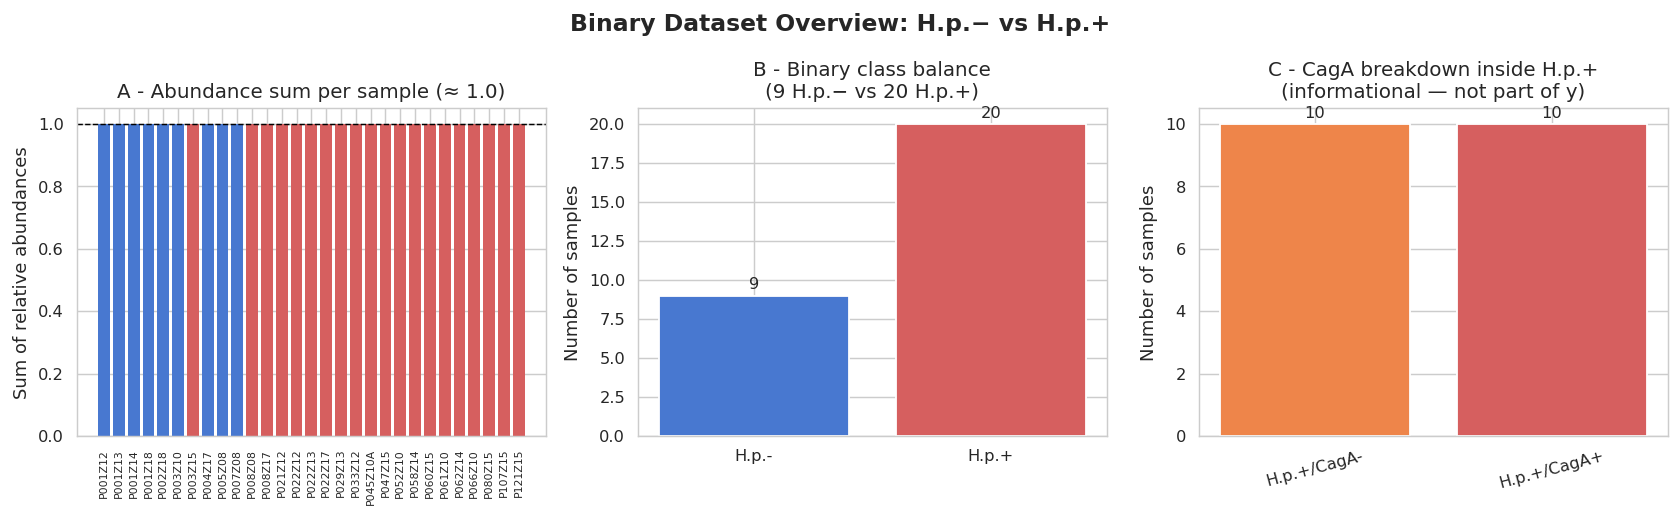

In [37]:
# Fig 01: Dataset overview
# Walsh et al. (2024) Step 2: 'Get to know your data' BEFORE modelling.
# EDA is performed on all 29 samples before any train/test split.

# With a binary classifier, the critical check is CLASS BALANCE.
# We have 9 negatives vs 20 positives (ratio ≈ 1:2.2).
# Walsh et al. (2024): unbalanced classes can lead to inaccurate models.
# At this ratio the imbalance is moderate - monitor precision/recall
# separately for each class, not just overall accuracy.

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Panel A — abundance sum sanity check, coloured by binary label
ax = axes[0]
ax.bar(range(len(otu)), otu.sum(axis=1).values,
       color=[BINARY_COLORS[l] for l in labels], edgecolor='none')
ax.axhline(1.0, color='black', lw=0.8, linestyle='--')
ax.set_xticks(range(len(otu)))
ax.set_xticklabels(otu.index, rotation=90, fontsize=6)
ax.set_ylabel('Sum of relative abundances')
ax.set_title('A - Abundance sum per sample (≈ 1.0)')

# Panel B — binary class counts
ax = axes[1]
lc = labels.value_counts().reindex(BINARY_ORDER)
bars = ax.bar(lc.index, lc.values,
              color=[BINARY_COLORS[s] for s in lc.index], edgecolor='white')
ax.bar_label(bars, padding=2)
ax.set_ylabel('Number of samples')
ax.set_title('B - Binary class balance\n(9 H.p.− vs 20 H.p.+)')

# Panel C — CagA breakdown WITHIN H.p.+ (informational only, not used in y)
ax = axes[2]
hp_pos_breakdown = labels_3class[labels == 'H.p.+'].value_counts()
# Only H.p.+ samples; shows how CagA splits within the positive class.
bars2 = ax.bar(hp_pos_breakdown.index, hp_pos_breakdown.values,
               color=[CAGA_COLORS[s] for s in hp_pos_breakdown.index],
               edgecolor='white')
ax.bar_label(bars2, padding=2)
ax.set_ylabel('Number of samples')
ax.set_title('C - CagA breakdown inside H.p.+\n(informational — not part of y)')
ax.tick_params(axis='x', rotation=15)

plt.suptitle('Binary Dataset Overview: H.p.− vs H.p.+', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig01_binary_overview.png', dpi=150, bbox_inches='tight')
plt.show()

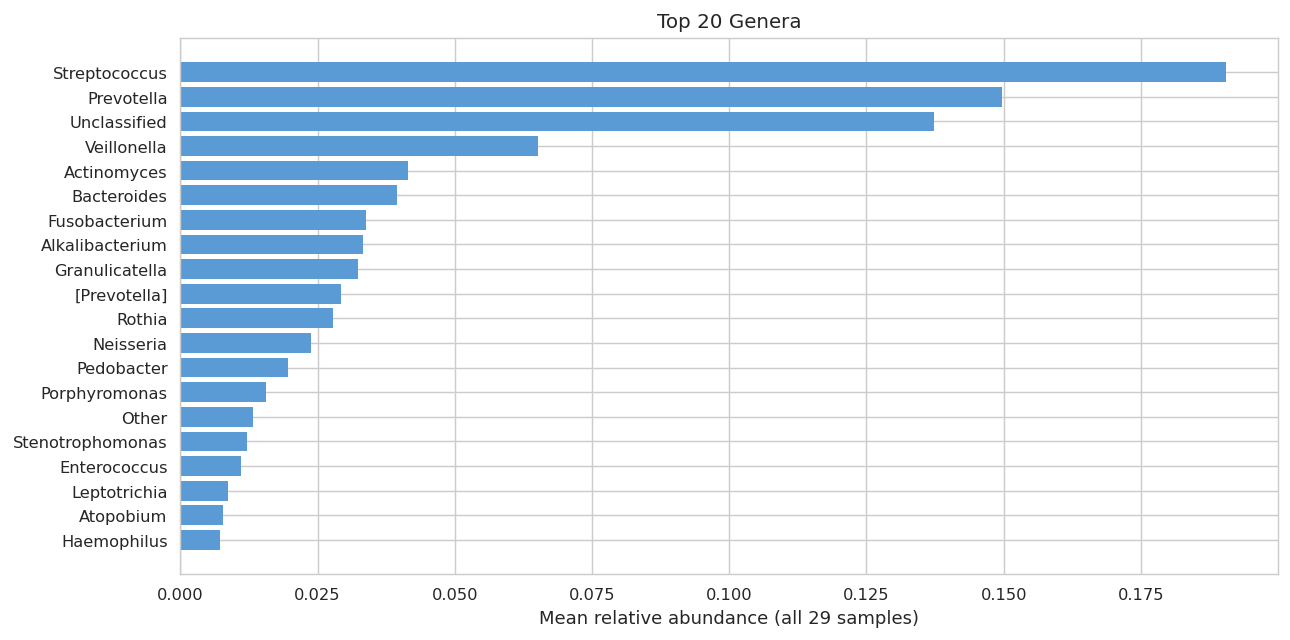

In [49]:
# Fig 02: Top 20 genera by mean relative abundance
# Durán et al. (2021): Helicobacter is dominant in H.p.+ samples and will
# strongly drive the binary classifier. The DL team should test models
# WITH and WITHOUT Helicobacter to assess whether the rest of the
# community carries independent predictive information.

top20 = otu.mean(axis=0).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 5))
bar_c = ['#c0392b' if g == 'Helicobacter' else '#5b9bd5' for g in top20.index]
ax.barh(top20.index[::-1], top20.values[::-1],
        color=bar_c[::-1], edgecolor='none')
ax.set_xlabel('Mean relative abundance (all 29 samples)')
ax.set_title('Top 20 Genera')
#heli = top20['Helicobacter']
#ax.annotate(f'Helicobacter: {heli:.2f}',
#            xy=(heli, 0), xytext=(heli - 0.10, 1.8),
#            arrowprops=dict(arrowstyle='->', color='black', lw=0.8),
#            fontsize=8, color='darkred')
plt.tight_layout()
plt.savefig('fig02_top20_genera.png', dpi=150, bbox_inches='tight')
plt.show()

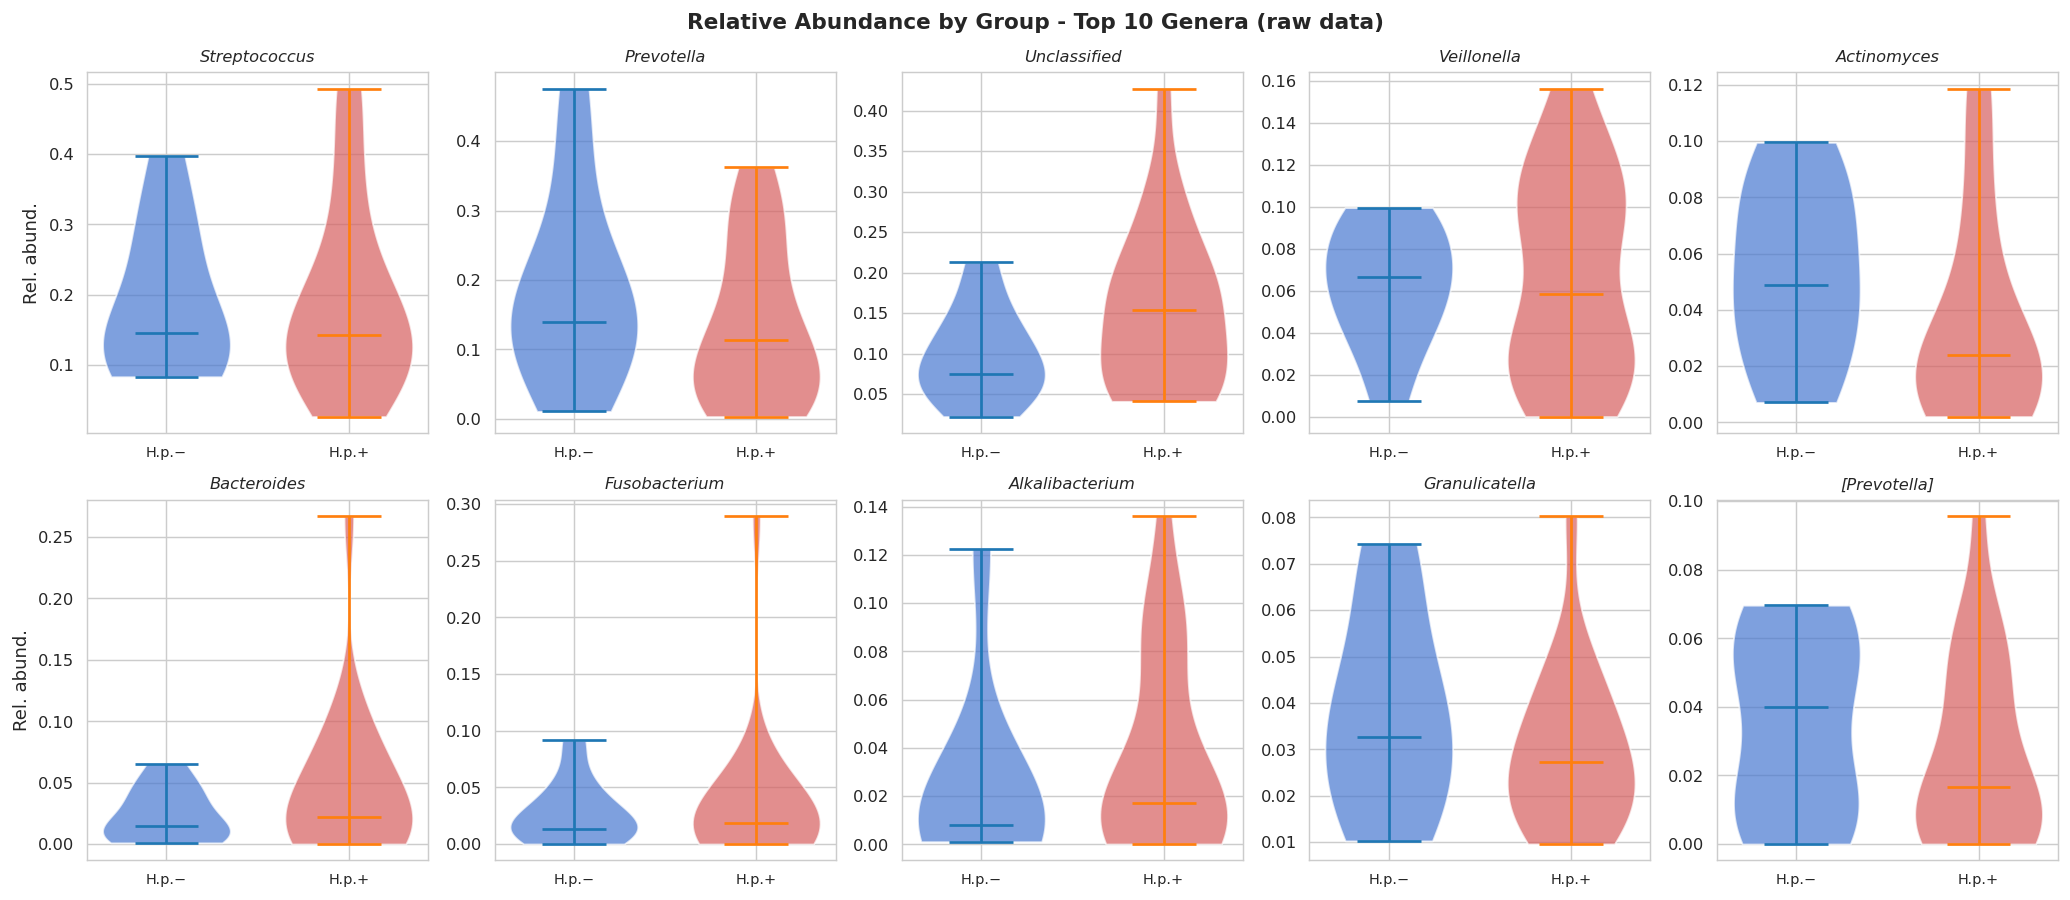

In [39]:
# Fig 03: Per-group violins of raw relative abundances (top 10 genera)
# BINARY comparison: H.p.- vs H.p.+
# Shows whether group differences are already visible in untransformed data.

top10 = otu.mean(axis=0).sort_values(ascending=False).head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.ravel()

for i, genus in enumerate(top10):
    ax = axes[i]
    for j, status in enumerate(BINARY_ORDER):  # ['H.p.-', 'H.p.+']
        mask   = labels == status
        values = otu.loc[mask, genus].values
        parts  = ax.violinplot(values, positions=[j],
                               showmedians=True, widths=0.7)
        for pc in parts['bodies']:
            pc.set_facecolor(list(BINARY_COLORS.values())[j])
            pc.set_alpha(0.7)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['H.p.−', 'H.p.+'], fontsize=8)
    ax.set_title(genus, fontsize=9, style='italic')
    ax.set_ylabel('Rel. abund.' if i % 5 == 0 else '')

plt.suptitle('Relative Abundance by Group - Top 10 Genera (raw data)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig03_binary_violins_raw.png', dpi=150, bbox_inches='tight')
plt.show()

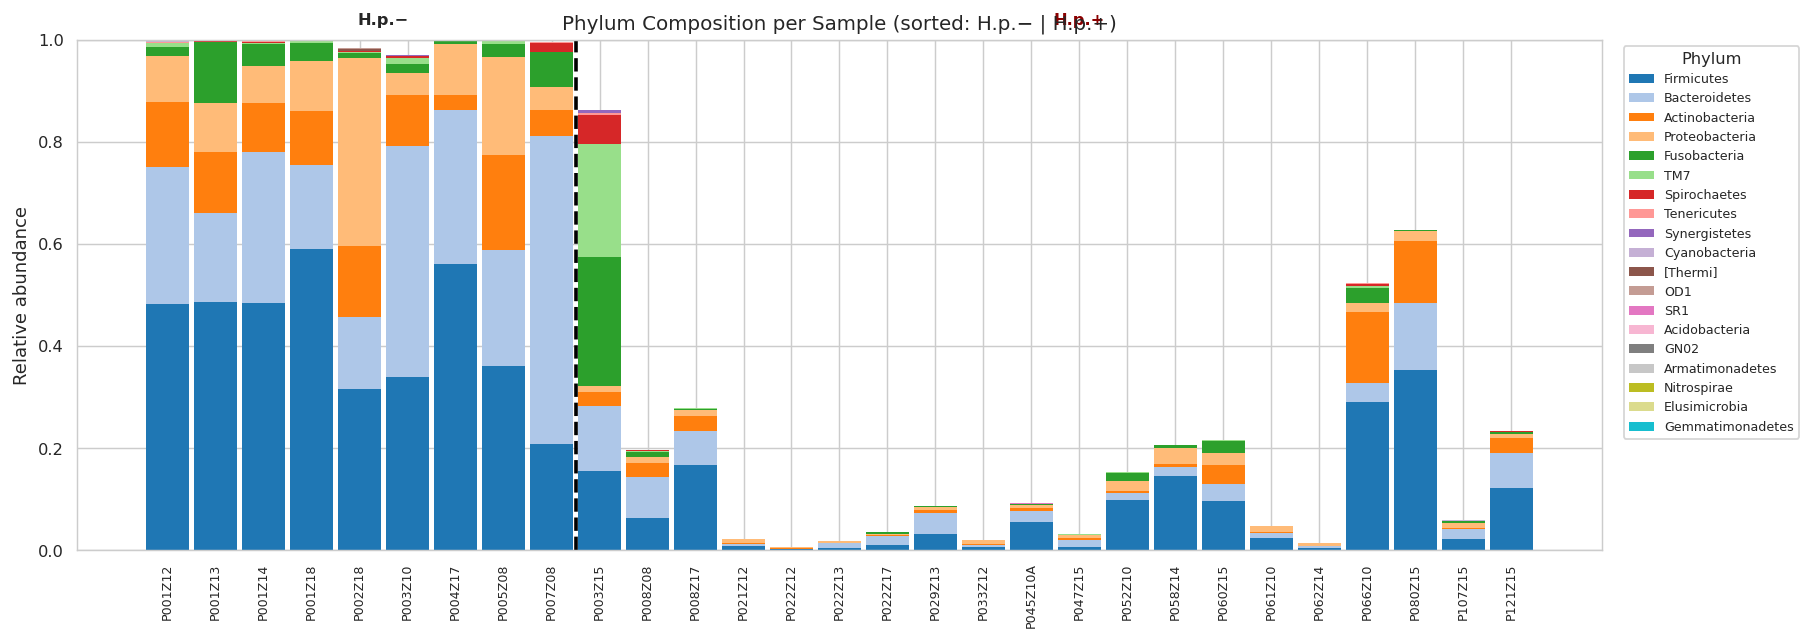

In [40]:
# Fig 04: Phylum-level stacked bar chart, sorted by binary label

otu_phylum = dfp_m.pivot_table(
    index='Sample_ID', columns='phylum',
    values='Abundances', aggfunc='sum'
).fillna(0)

phylum_order   = otu_phylum.mean(axis=0).sort_values(ascending=False).index
otu_phy_sorted = otu_phylum[phylum_order].loc[group_order_idx]
palette_phyla  = sns.color_palette('tab20', n_colors=len(phylum_order))

fig, ax = plt.subplots(figsize=(14, 5))
bottoms = np.zeros(len(otu_phy_sorted))
for phylum, color in zip(phylum_order, palette_phyla):
    vals = otu_phy_sorted[phylum].values
    ax.bar(range(len(otu_phy_sorted)), vals, bottom=bottoms,
           color=color, label=phylum, edgecolor='none', width=0.9)
    bottoms += vals

# Single separator line between H.p.- and H.p.+
ax.axvline(n_neg - 0.5, color='black', lw=2, linestyle='--')
ax.text(n_neg/2,    1.03, 'H.p.−', ha='center', fontsize=9,
        fontweight='bold', transform=ax.get_xaxis_transform())
ax.text(n_neg + n_pos/2, 1.03, 'H.p.+', ha='center', fontsize=9,
        fontweight='bold', color='darkred',
        transform=ax.get_xaxis_transform())

ax.set_xticks(range(len(otu_phy_sorted)))
ax.set_xticklabels(otu_phy_sorted.index, rotation=90, fontsize=7)
ax.set_ylabel('Relative abundance')
ax.set_title('Phylum Composition per Sample (sorted: H.p.− | H.p.+)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7, title='Phylum')
plt.tight_layout()
plt.savefig('fig04_phylum_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

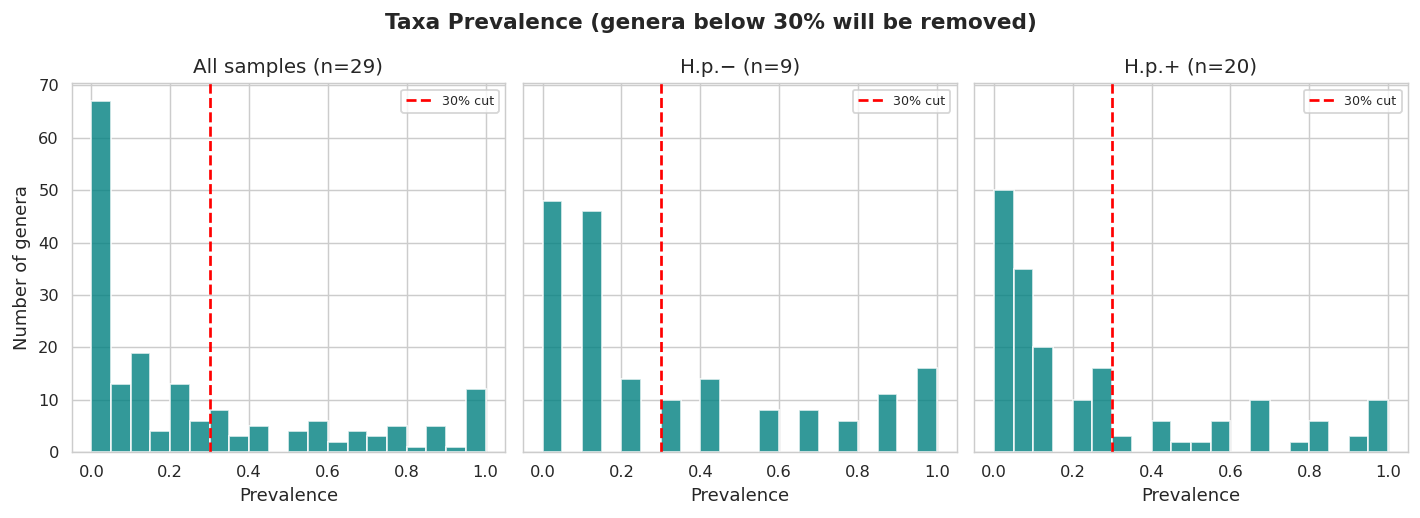

  >= 10% of samples: 101 genera
  >= 30% of samples: 59 genera
  >= 50% of samples: 43 genera


In [41]:
# Fig 05: Prevalence distribution - overall and per group
# Prevalence = fraction of samples in which a genus is detected (count > 0).
# Walsh et al. (2024): abundance/prevalence filtering removes rare/spurious
# taxa that add noise without biological signal (GIGO principle).
# With n=29, we lower the threshold to 30% (~9 samples) to retain enough
# features for the ML models.

fig, axes = plt.subplots(1, 3, figsize=(11, 4), sharey=True)
titles = ['All samples (n=29)', 'H.p.− (n=9)', 'H.p.+ (n=20)']
masks  = [
    pd.Series([True]*len(otu), index=otu.index),
    labels == 'H.p.-',
    labels == 'H.p.+',
]
for ax, title, mask in zip(axes, titles, masks):
    prev = (otu.loc[mask] > 0).mean(axis=0)
    ax.hist(prev, bins=20, color='teal', edgecolor='white', alpha=0.8)
    ax.axvline(0.30, color='red', linestyle='--', lw=1.5, label='30% cut')
    ax.set_xlabel('Prevalence')
    ax.set_title(title)
    ax.legend(fontsize=7)
axes[0].set_ylabel('Number of genera')

prev_all = (otu > 0).mean(axis=0)
plt.suptitle('Taxa Prevalence (genera below 30% will be removed)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig05_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()

for thr in [0.10, 0.30, 0.50]:
    print(f'  >= {thr:.0%} of samples: {(prev_all >= thr).sum()} genera')

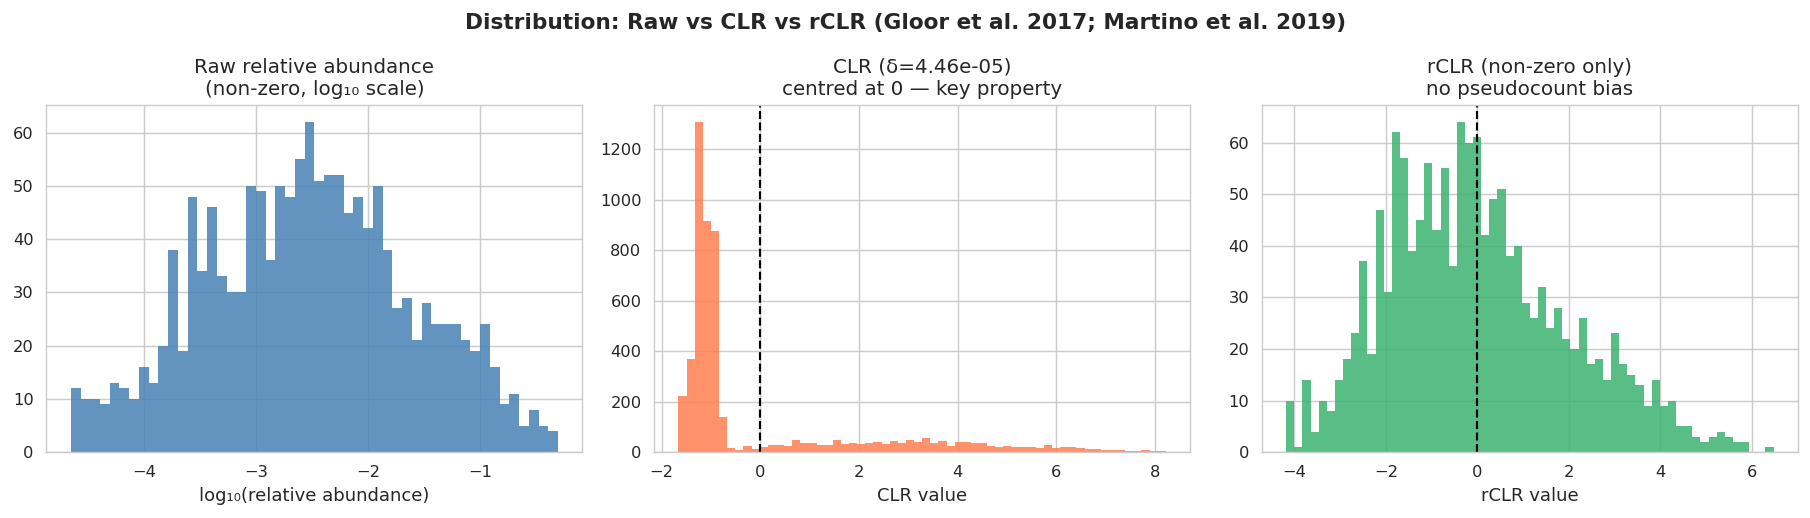

In [42]:
# Fig 06: Distribution - Raw vs CLR vs rCLR
# This is the most important quality-control plot after CLR.
# Expected after CLR: roughly bell-shaped, centred at 0.
# Gloor et al. (2017): log-ratio transformation makes the data
# 'symmetric and linearly related' - visible as a near-normal distribution.

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

raw_nz = otu.values[otu.values > 0]
axes[0].hist(np.log10(raw_nz), bins=50, color='steelblue',
             edgecolor='none', alpha=0.85)
axes[0].set_xlabel('log₁₀(relative abundance)')
axes[0].set_title('Raw relative abundance\n(non-zero, log₁₀ scale)')

axes[1].hist(otu_clr.values.ravel(), bins=60, color='coral',
             edgecolor='none', alpha=0.85)
axes[1].axvline(0, color='black', lw=1.2, linestyle='--')
axes[1].set_xlabel('CLR value')
axes[1].set_title(f'CLR (δ={PSEUDOCOUNT:.2e})\ncentred at 0 — key property')

rclr_nz = otu_rclr.values[otu_rclr.values != 0]
axes[2].hist(rclr_nz, bins=60, color='mediumseagreen',
             edgecolor='none', alpha=0.85)
axes[2].axvline(0, color='black', lw=1.2, linestyle='--')
axes[2].set_xlabel('rCLR value')
axes[2].set_title('rCLR (non-zero only)\nno pseudocount bias')

plt.suptitle('Distribution: Raw vs CLR vs rCLR (Gloor et al. 2017; Martino et al. 2019)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig06_distribution_clr.png', dpi=150, bbox_inches='tight')
plt.show()

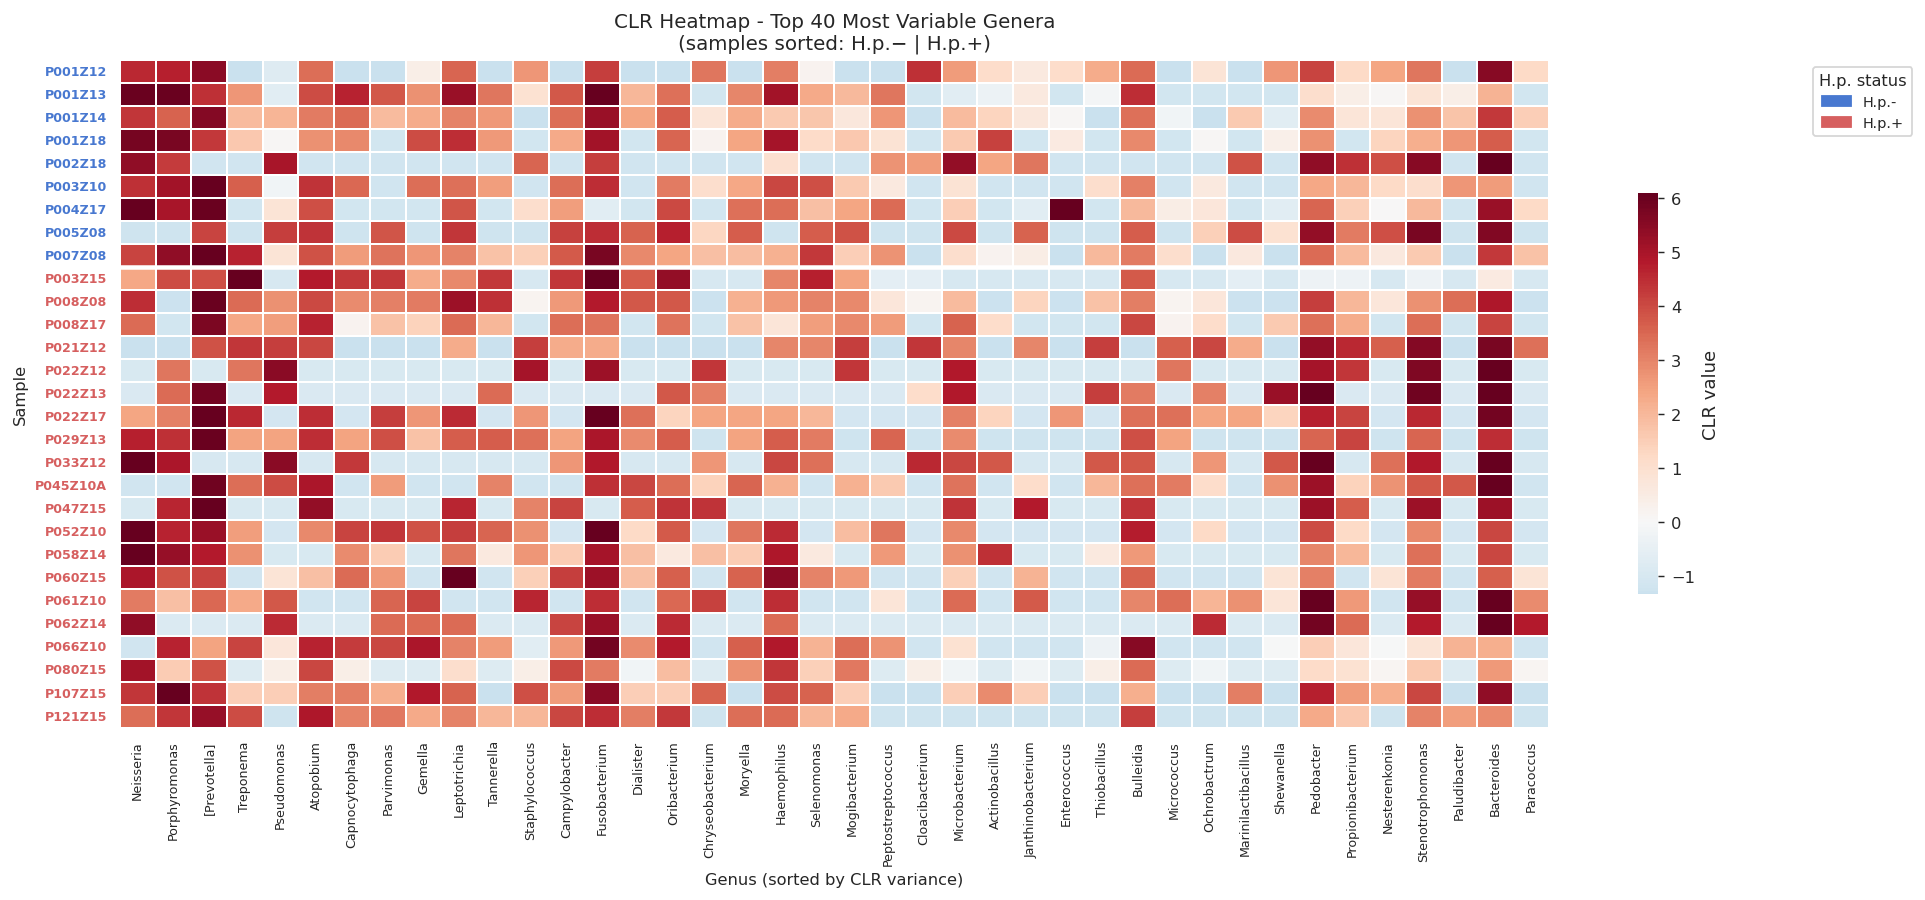

In [43]:
# Fig 07: CLR heatmap — top 40 most variable genera
# Per Gloor et al. (2017): 'in PCA biplots the OTUs that have the largest
# variation in the dataset' are the most informative. Variance in CLR space
# is the correct measure of variability for compositional data.

clr_var = otu_clr.var(axis=0).sort_values(ascending=False)
# .var(axis=0): variance of each column (genus) across all 29 samples.
# High variance → genus fluctuates strongly between samples → potentially
# discriminative between H.p. status groups
top40   = clr_var.head(40).index
clr_top40_sorted = otu_clr.loc[group_order_idx, top40]
# .loc[group_order_idx, top40]: rows reordered (H.p.-/CagA-/CagA+)

fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(
    clr_top40_sorted,
    cmap='RdBu_r',
    # Blue = depleted vs geometric mean (negative CLR)
    # White = at the geometric mean (CLR ≈ 0)
    # Red = enriched vs geometric mean (positive CLR)
    center=0,     # white fixed at CLR = 0
    robust=True,  # 2nd–98th percentile for colour scaling
    linewidths=0.1, linecolor='white',
    ax=ax,
    cbar_kws={'label': 'CLR value', 'shrink': 0.6}
)
ax.set_xlabel('Genus (sorted by CLR variance)', fontsize=9)
ax.set_ylabel('Sample', fontsize=9)
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', rotation=0,  labelsize=7)

# Colour y-axis labels by binary group
_lc = [BINARY_COLORS[labels[otu.index.get_loc(s)]] for s in group_order_idx]
for ytick, color in zip(ax.get_yticklabels(), _lc):
    ytick.set_color(color)
    ytick.set_fontweight('bold')

# Separator line between H.p.- and H.p.+
ax.axhline(n_neg, color='white', lw=2.5)

handles = [mpatches.Patch(color=c, label=l) for l, c in BINARY_COLORS.items()]
ax.legend(handles=handles, title='H.p. status',
          bbox_to_anchor=(1.18, 1), loc='upper left', fontsize=8)
ax.set_title('CLR Heatmap - Top 40 Most Variable Genera\n'
             '(samples sorted: H.p.− | H.p.+)', fontsize=11)
plt.tight_layout()
plt.savefig('fig07_clr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

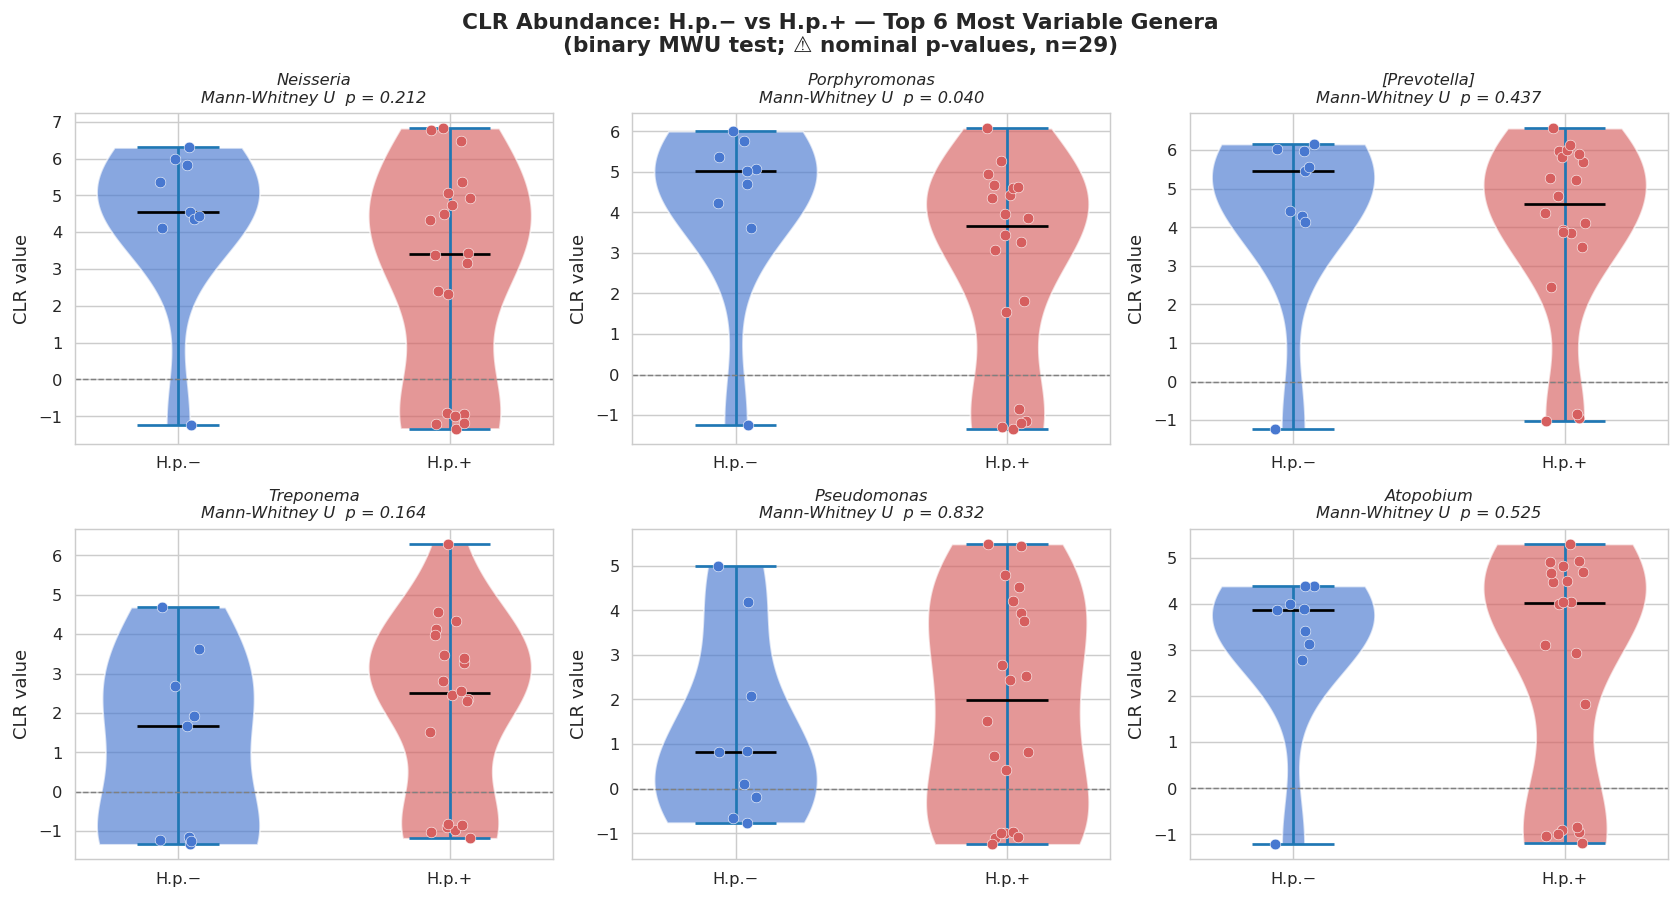

In [44]:
# Fig 08: CLR violins for top 6 most variable genera (binary comparison)
# Mann-Whitney U test: non-parametric, no normality assumption.
top6 = clr_var.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.ravel()

for i, genus in enumerate(top6):
    ax     = axes[i]
    g_neg  = otu_clr.loc[labels == 'H.p.-', genus].values
    g_pos  = otu_clr.loc[labels == 'H.p.+', genus].values

    vparts = ax.violinplot([g_neg, g_pos], positions=[0, 1],
                           showmedians=True, widths=0.6)
    for j, pc in enumerate(vparts['bodies']):
        pc.set_facecolor(list(BINARY_COLORS.values())[j])
        pc.set_alpha(0.65)
    vparts['cmedians'].set_colors('black')
    vparts['cmedians'].set_linewidth(1.5)

    # Individual jittered points
    rng = np.random.default_rng(42)
    for j, (grp, vals) in enumerate(zip(BINARY_ORDER, [g_neg, g_pos])):
        x = rng.uniform(j - 0.08, j + 0.08, size=len(vals))
        ax.scatter(x, vals, color=list(BINARY_COLORS.values())[j],
                   edgecolors='white', lw=0.3, s=35, zorder=3)

    # Mann-Whitney U — binary comparison
    _, pval = mannwhitneyu(g_neg, g_pos, alternative='two-sided')
    # More statistical power than Kruskal-Wallis because we have 2 groups
    # instead of 3, and more samples per group (9 vs 20 instead of ~9-10 each).
    ax.set_title(f'{genus}\nMann-Whitney U  p = {pval:.3f}',
                 fontsize=9, style='italic')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['H.p.−', 'H.p.+'], fontsize=9)
    ax.set_ylabel('CLR value')
    ax.axhline(0, color='grey', lw=0.8, linestyle='--')

plt.suptitle('CLR Abundance: H.p.− vs H.p.+ — Top 6 Most Variable Genera\n'
             '(binary MWU test; ⚠ nominal p-values, n=29)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig08_clr_violins_binary.png', dpi=150, bbox_inches='tight')
plt.show()

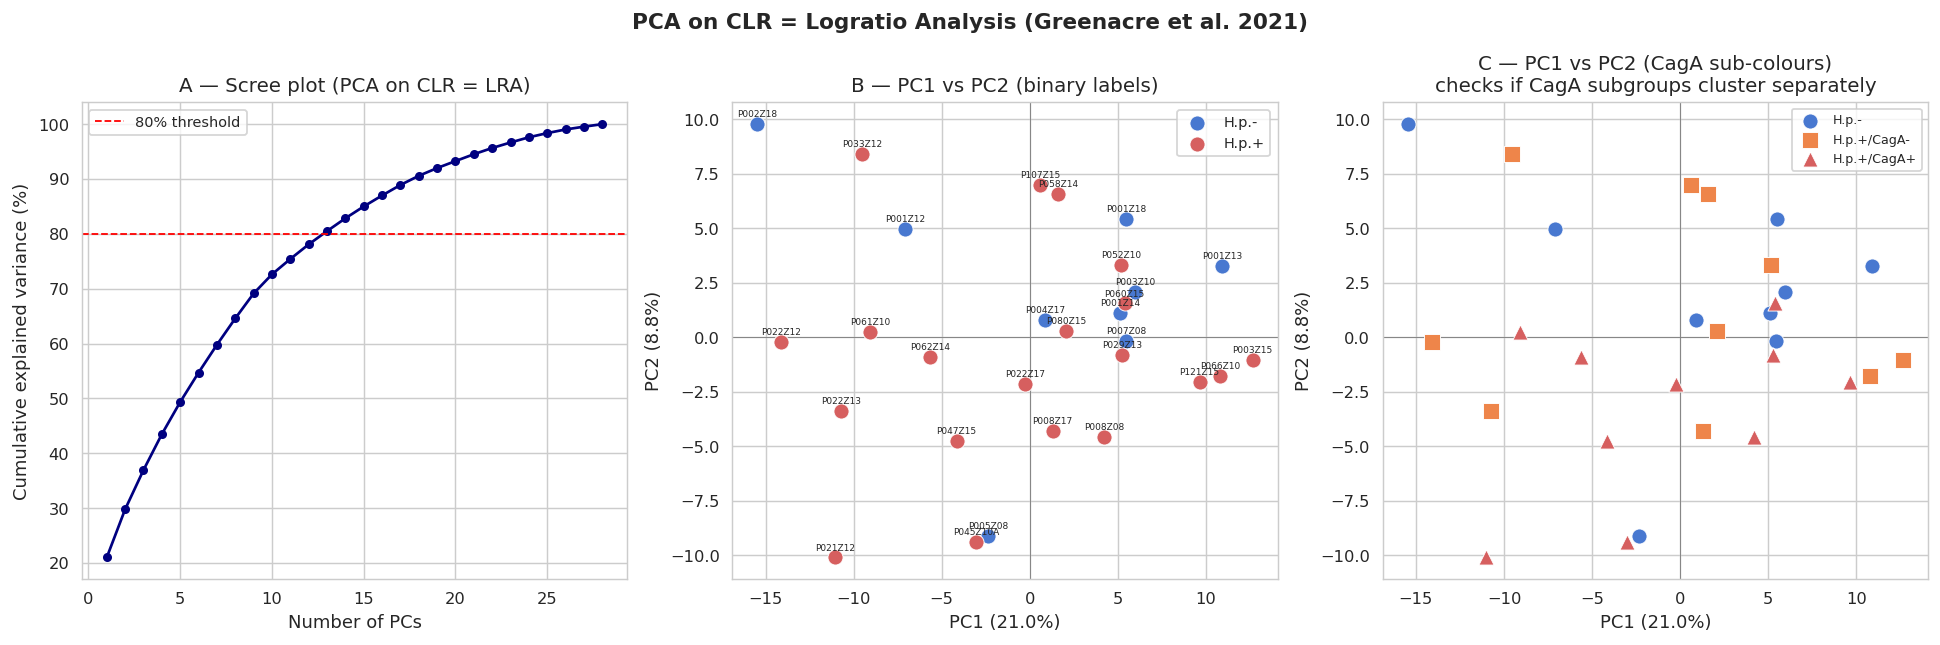

PC1=21.0%  PC2=8.8%  PC3=7.2%


In [50]:
# Fig 09: PCA on CLR = Logratio Analysis.
# Greenacre et al. (2021): 'the LRA of the full dataset based on all pairwise
# logratios is equivalent to PCA of the CLR-transformed matrix'.
# The PCA biplot shows which samples differ in composition and which genera
# drive those differences.
# Gloor et al. (2017): ordination in CLR space is driven by the MOST VARIABLE
# features — superior to PCoA which can be dominated by abundant taxa.
# Binary colour scheme: blue = H.p.-, red = H.p.+
# CagA status shown as marker shape to visualise whether the two H.p.+
# subgroups cluster separately even though they share the same label.

pca = PCA(n_components=min(len(otu)-1, otu_clr.shape[1]-1), random_state=42)
# n_components: CLR data has rank D-1 because the zero-sum constraint
# removes one degree of freedom (Gloor et al. 2017, Gloor supplement).
# 'singular covariance matrix' - at most min(n_samples-1, n_genera-1) PCs
# will have non-zero variance.
# random_state=42: seeds the randomised SVD solver for reproducibility.
clr_pca  = pca.fit_transform(otu_clr.values)
# fit_transform:
#   1. fit: learn the principal directions (eigenvectors of the CLR
#           covariance matrix) from otu_clr.values.
#   2. transform: project each sample onto those directions.
# Input shape : (29, 182). Output shape: (29, n_components).
# IMPORTANT: Walsh et al. (2024) Step 3 says transformations that use
# information across samples should be fit on training data only.
# Here PCA is used purely for VISUALISATION (EDA), not as a preprocessing
# step before ML. For ML, re-fit PCA inside the CV loop.

explained = pca.explained_variance_ratio_
# Array of length n_components: fraction of total variance explained by each PC.
# Sums to < 1.0 (some variance is in the remaining components).

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel A - scree plot
ax = axes[0]
ax.plot(range(1, len(explained)+1), np.cumsum(explained)*100,
        'o-', color='navy', markersize=4)
ax.axhline(80, color='red', lw=1, linestyle='--', label='80% threshold')
ax.set_xlabel('Number of PCs')
ax.set_ylabel('Cumulative explained variance (%)')
ax.set_title('A — Scree plot (PCA on CLR = LRA)')
ax.legend(fontsize=8)

# Panel B - PC1 vs PC2, binary colours
ax = axes[1]
for status in BINARY_ORDER:
    mask = labels == status
    ax.scatter(clr_pca[mask, 0], clr_pca[mask, 1],
               c=BINARY_COLORS[status], label=status,
               s=70, edgecolors='white', lw=0.5, zorder=3)
for i, sid in enumerate(otu.index):
    ax.annotate(sid, (clr_pca[i, 0], clr_pca[i, 1]),
                fontsize=5, ha='center', va='bottom',
                xytext=(0, 3), textcoords='offset points')
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax.set_title('B — PC1 vs PC2 (binary labels)')
ax.legend(fontsize=8)
ax.axhline(0, color='grey', lw=0.5); ax.axvline(0, color='grey', lw=0.5)

# Panel C - PC1 vs PC2, CagA sub-colouring to visualise internal structure
ax = axes[2]
caga_markers = {'H.p.-': 'o', 'H.p.+/CagA-': 's', 'H.p.+/CagA+': '^'}
for status3 in ['H.p.-', 'H.p.+/CagA-', 'H.p.+/CagA+']:
    mask3 = labels_3class == status3
    ax.scatter(clr_pca[mask3, 0], clr_pca[mask3, 1],
               c=CAGA_COLORS[status3], marker=caga_markers[status3],
               label=status3, s=70, edgecolors='white', lw=0.5, zorder=3)
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax.set_title('C — PC1 vs PC2 (CagA sub-colours)\n'
             'checks if CagA subgroups cluster separately')
ax.legend(fontsize=7)
ax.axhline(0, color='grey', lw=0.5); ax.axvline(0, color='grey', lw=0.5)

plt.suptitle('PCA on CLR = Logratio Analysis (Greenacre et al. 2021)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig09_pca_binary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'PC1={explained[0]*100:.1f}%  PC2={explained[1]*100:.1f}%  PC3={explained[2]*100:.1f}%')

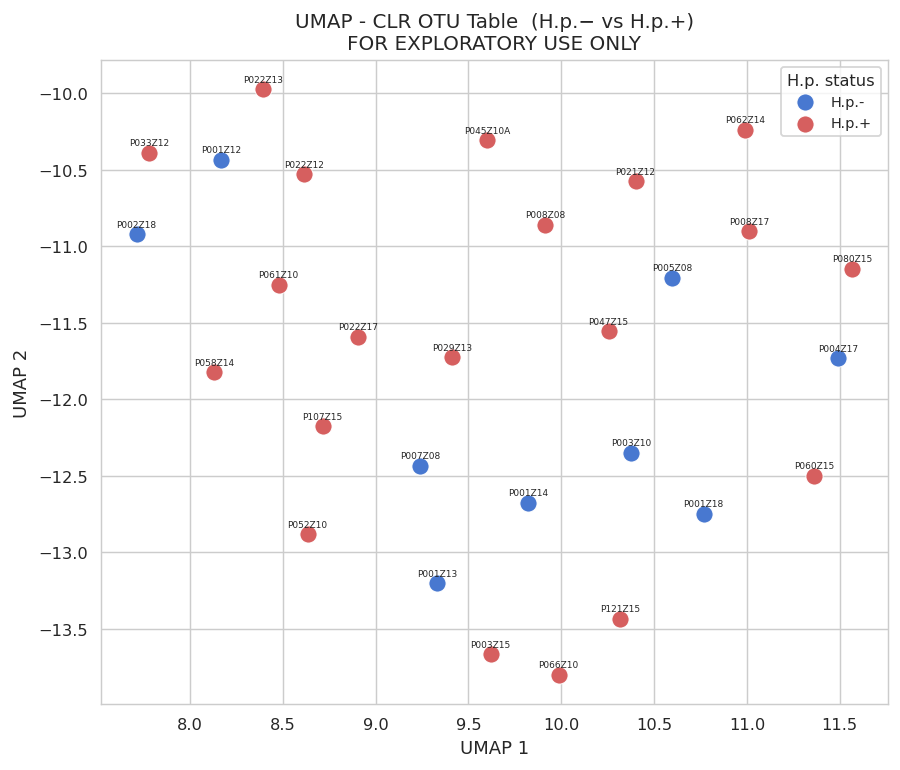

In [51]:
# Fig 10: UMAP embedding
# Durán et al. (2021) showed that with gastric microbiome data from the SAME
# study (Paroni Sterbini et al.), PCA FAILED to separate H. pylori-treated
# from untreated samples, while non-linear methods (MCE, their method)
# succeeded.  UMAP is a modern non-linear alternative.
# NOTE: with n=29, any embedding is EXPLORATORY. Do not over-interpret.

reducer = umap.UMAP(
    n_neighbors=8,
    # Number of nearest neighbours used to build the local graph.
    # Must be < n_samples. Rule of thumb: ~sqrt(n) ≈ sqrt(29) ≈ 5-8.
    # Low n_neighbors → fine local structure; high → global topology.
    # The default (15) is too large for n=29.
    min_dist=0.2,
    # Minimum distance between points in the 2D embedding.
    # Low -> compact clusters; high -> dispersed layout.
    n_components=2,
    # Output dimensionality (2 for 2D scatter plot).
    metric='euclidean',  # Euclidean in CLR space = Aitchison distance
    random_state=42
)
clr_umap = reducer.fit_transform(otu_clr.values)
# fit_transform: learn the non-linear manifold and project to 2D.
# Input shape: (29, 182). Output shape: (29, 2).

fig, ax = plt.subplots(figsize=(7, 6))
for status in BINARY_ORDER:
    mask = labels == status
    ax.scatter(clr_umap[mask, 0], clr_umap[mask, 1],
               c=BINARY_COLORS[status], label=status,
               s=90, edgecolors='white', lw=0.5, zorder=3)
for i, sid in enumerate(otu.index):
    ax.annotate(sid, (clr_umap[i, 0], clr_umap[i, 1]),
                fontsize=5, ha='center', va='bottom',
                xytext=(0, 3), textcoords='offset points')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_title('UMAP - CLR OTU Table  (H.p.− vs H.p.+)\n'
             'FOR EXPLORATORY USE ONLY')
ax.legend(title='H.p. status', fontsize=8)
plt.tight_layout()
plt.savefig('fig10_umap_binary.png', dpi=150, bbox_inches='tight')
plt.show()

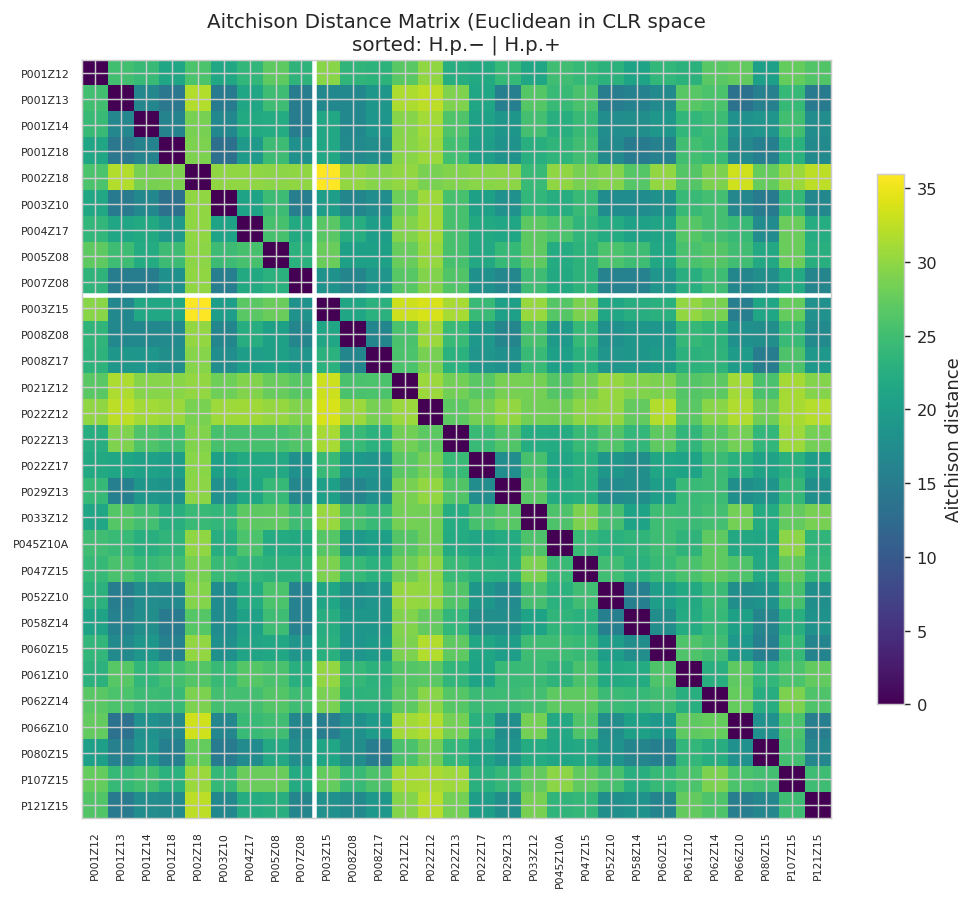

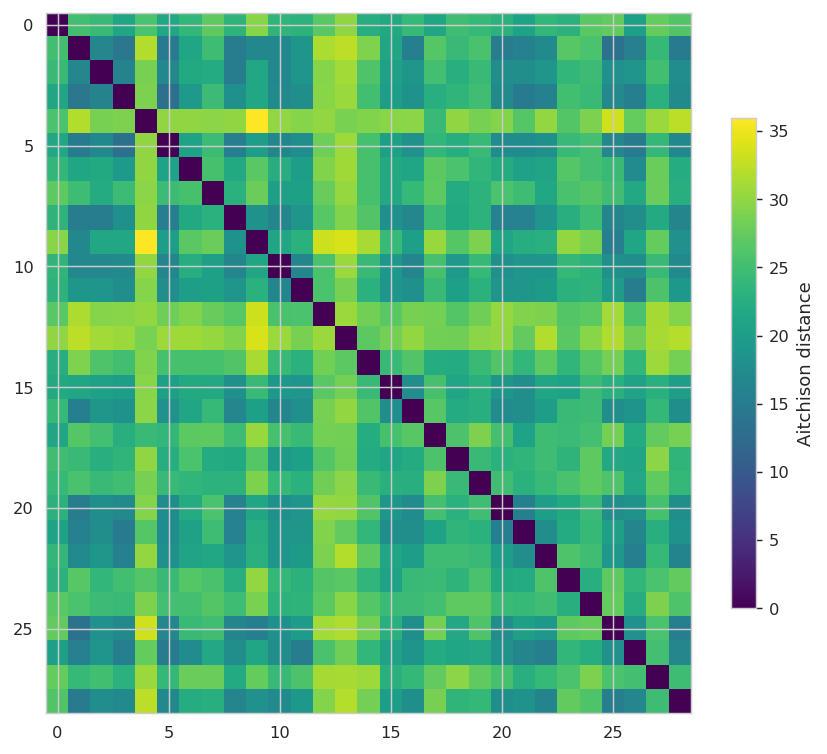

In [52]:
# Fig 11: Aitchison distance matrix
# Gloor et al. (2017): 'the Aitchison distance is superior to both
# Jensen-Shannon divergence and the Bray-Curtis dissimilarity metrics,
# being more stable to subsetting and aggregating, and being a true
# linear distance'.
# Euclidean distance in CLR space = Aitchison distance (Gloor 2017, eq. 2).
# If within-group distances < between-group distances, the lighter
# diagonal blocks will be visible.

ait_dist   = squareform(pdist(otu_clr.values, metric='euclidean'))
# pdist(X, metric): computes pairwise distances between all rows of X.
#   metric='euclidean': sqrt(sum((a-b)^2)) for each pair.
#   Returns a condensed 1D array of n*(n-1)/2 distances (upper triangle).
# squareform: converts condensed 1D vector → symmetric (29×29) square matrix.
#   ait_dist[i,j] = ait_dist[j,i] = Aitchison distance between samples i and j.

ait_df     = pd.DataFrame(ait_dist, index=otu_clr.index, columns=otu_clr.index)
ait_sorted = ait_df.loc[group_order_idx, group_order_idx]
# Reorder BOTH rows and columns to group by H.p. status.
# If within-group distances < between-group distances, the block diagonal
# of the matrix will appear lighter (more similar within groups).

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(ait_sorted.values, cmap='viridis', aspect='auto')
# imshow: display matrix as a colour-coded image.
# cmap='viridis': perceptually uniform colourmap. Dark = small distance.
# aspect='auto': stretch cells to fill the axes area.

plt.colorbar(im, ax=ax, label='Aitchison distance', shrink=0.7)
# colorbar: adds a legend showing distance ↔ colour mapping.

# White separator lines between the groups
ax.axhline(n_neg - 0.5, color='white', lw=2.5)
ax.axvline(n_neg - 0.5, color='white', lw=2.5)

ax.set_xticks(range(len(ait_sorted)))
ax.set_xticklabels(ait_sorted.index, rotation=90, fontsize=6)
ax.set_yticks(range(len(ait_sorted)))
ax.set_yticklabels(ait_sorted.index, fontsize=6)
ax.set_title('Aitchison Distance Matrix (Euclidean in CLR space\n'
             'sorted: H.p.− | H.p.+')
plt.tight_layout()
plt.savefig('fig11_aitchison_binary.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(ait_sorted.values, cmap='viridis', aspect='auto')
plt.colorbar(im, ax=ax, label='Aitchison distance', shrink=0.7)

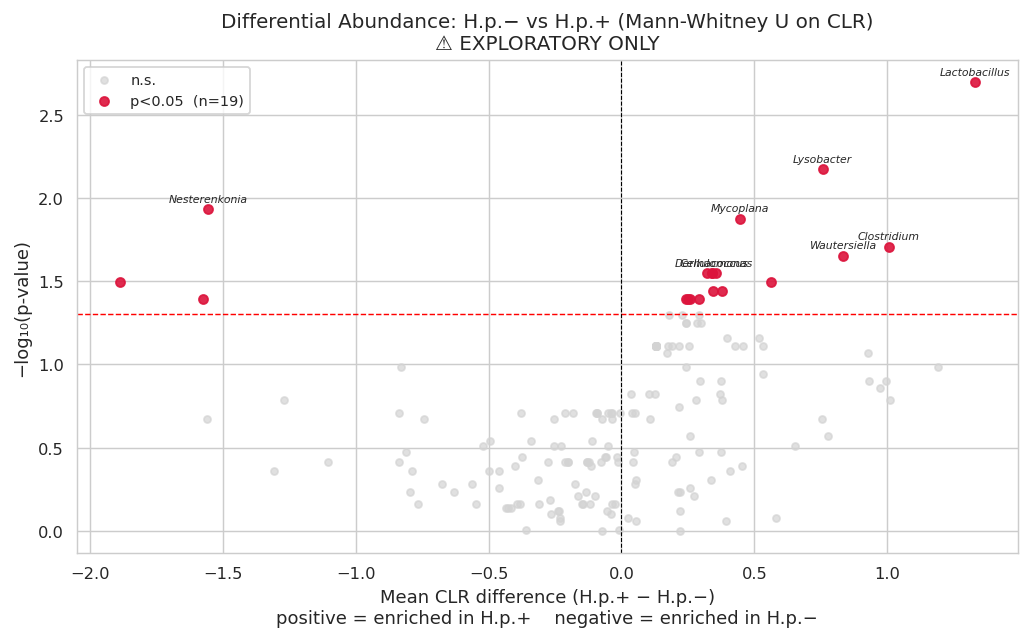

Genera with nominal p < 0.05: 19 / 181


In [53]:
# Fig 12: Volcano plots - differential abundance in CLR space
# Mann-Whitney U test on CLR values (Gloor et al. 2017 supplement;
# Gloor recommends ALDEx2 for a rigorous CoDA-based differential test,
# but MWU on CLR values is a valid non-parametric exploratory approach).
# Single comparison: H.p.- vs H.p.+ (all positives pooled).
# With 9 vs 20 samples, MWU has more power than the previous 3-group test.

pvals, mean_diffs = [], []
g_neg_all = otu_clr.loc[labels == 'H.p.-']
g_pos_all = otu_clr.loc[labels == 'H.p.+']

for genus in otu_clr.columns:
    a = g_neg_all[genus].values
    b = g_pos_all[genus].values
    try:
        _, p = mannwhitneyu(a, b, alternative='two-sided')
                # alternative='two-sided': test for ANY direction of difference.
            # mannwhitneyu: non-parametric, no normality assumption.
            # Appropriate for n~9-10 per group.
    except ValueError:
        p = 1.0
        # ValueError if all values are identical (constant genus) - set p=1
    pvals.append(p)
    mean_diffs.append(b.mean() - a.mean())
    # Positive mean_diff: genus enriched in H.p.+
    # Negative mean_diff: genus enriched in H.p.-

pvals      = np.array(pvals)
mean_diffs = np.array(mean_diffs)
neg_log_p  = -np.log10(pvals + 1e-300)
# -log10(p): transforms p-values so larger = more significant.
    # +1e-300: avoids log10(0) for extremely small p-values.
sig        = pvals < 0.05
# Significance mask.  NOTE: these are NOMINAL p-values (not corrected
    # for multiple testing).  Walsh et al. (2024): with n=29, statistical
    # power is limited - EXPLORATORY ONLY.

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(mean_diffs[~sig], neg_log_p[~sig],
           color='lightgrey', s=15, alpha=0.7, label='n.s.')
ax.scatter(mean_diffs[sig],  neg_log_p[sig],
           color='crimson',   s=25, alpha=0.9,
           label=f'p<0.05  (n={sig.sum()})')
ax.axhline(-np.log10(0.05), color='red',   lw=0.8, linestyle='--')
ax.axvline(0,               color='black', lw=0.6, linestyle='--')

# Label top 8 most significant genera
for idx in np.argsort(pvals)[:8]:
    ax.annotate(otu_clr.columns[idx],
                (mean_diffs[idx], neg_log_p[idx]),
                fontsize=6, ha='center', va='bottom',
                xytext=(0, 3), textcoords='offset points', style='italic')

ax.set_xlabel('Mean CLR difference (H.p.+ − H.p.−)\n'
              'positive = enriched in H.p.+    negative = enriched in H.p.−')
ax.set_ylabel('−log₁₀(p-value)')
ax.set_title('Differential Abundance: H.p.− vs H.p.+ (Mann-Whitney U on CLR)\n'
             '⚠ EXPLORATORY ONLY')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('fig12_volcano_binary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Genera with nominal p < 0.05: {sig.sum()} / {len(sig)}')

### Feature Engineering

1. Prevalence filter (biological quality filter — applied to all data)  
2. CLR transform (scale-invariant — does not leak information)  
3. TRAIN/VAL SPLIT  ← must happen BEFORE any fitted transforms  
4. Variance filter  ← fit on TRAIN only (Walsh et al. 2024 Step 4)  
5. StandardScaler   ← fit on TRAIN only  
6. (Optional) PCA   ← fit on TRAIN only  

Walsh et al. (2024): 'any transformation of data that uses information
across samples (scaling, standardisation, principal components analyses),
or feature selection, should be applied separately to training and test
data sets AFTER being split.'*

In [54]:
#Prevalence filter
MIN_PREVALENCE = 0.30
# Keep genera present in at least 30% of all 29 samples (~9 samples).
# Walsh et al. (2024): remove rare/spurious taxa before modelling (GIGO).

prev_all         = (otu > 0).mean(axis=0)
genera_keep_prev = prev_all[prev_all >= MIN_PREVALENCE].index
otu_filtered     = otu[genera_keep_prev].copy()
otu_clr_filtered = otu_clr[genera_keep_prev].copy()

print(f'Prevalence filter (>= {MIN_PREVALENCE:.0%}):')
print(f'  Before: {otu.shape[1]} genera')
print(f'  After : {otu_filtered.shape[1]} genera retained')

# CLR already applied
# CLR is scale-invariant (Gloor et al. 2017): the same values are obtained
# regardless of whether you start from raw counts or relative abundances.
# This means CLR does NOT use information across samples in a way that
# leaks test-set statistics — it is safe to apply before splitting.
print(f'\nCLR applied. Shape: {otu_clr_filtered.shape}')

# Label encoding
X_all = otu_clr_filtered.values.astype(np.float32)
# float32: PyTorch default dtype; avoids unnecessary memory usage.

y_all = (labels == 'H.p.+').astype(np.int64)
# H.p.- -> 0,  H.p.+ -> 1
# .astype(np.int64): required by PyTorch CrossEntropyLoss and BCELoss.

print(f'\nBinary label encoding:')
print(f'  0 = H.p.-  : {(y_all == 0).sum()} samples')
print(f'  1 = H.p.+  : {(y_all == 1).sum()} samples')
print(f'  X shape: {X_all.shape}  dtype: {X_all.dtype}')
print(f'  y shape: {y_all.shape}  dtype: {y_all.dtype}')

# Next steps happen inside the CV loop
# Walsh et al. (2024): variance filter and scaling must be fit on
# training folds only to avoid data leakage.

# Label Series for export
y_series = pd.Series(y_all, index=otu.index, name='label')
y_str    = pd.Series(
    ['H.p.+' if v == 1 else 'H.p.-' for v in y_all],
    index=otu.index, name='Hp_Status'
)

Prevalence filter (>= 30%):
  Before: 181 genera
  After : 59 genera retained

CLR applied. Shape: (29, 59)

Binary label encoding:
  0 = H.p.-  : 9 samples
  1 = H.p.+  : 20 samples
  X shape: (29, 59)  dtype: float32
  y shape: (29,)  dtype: int64


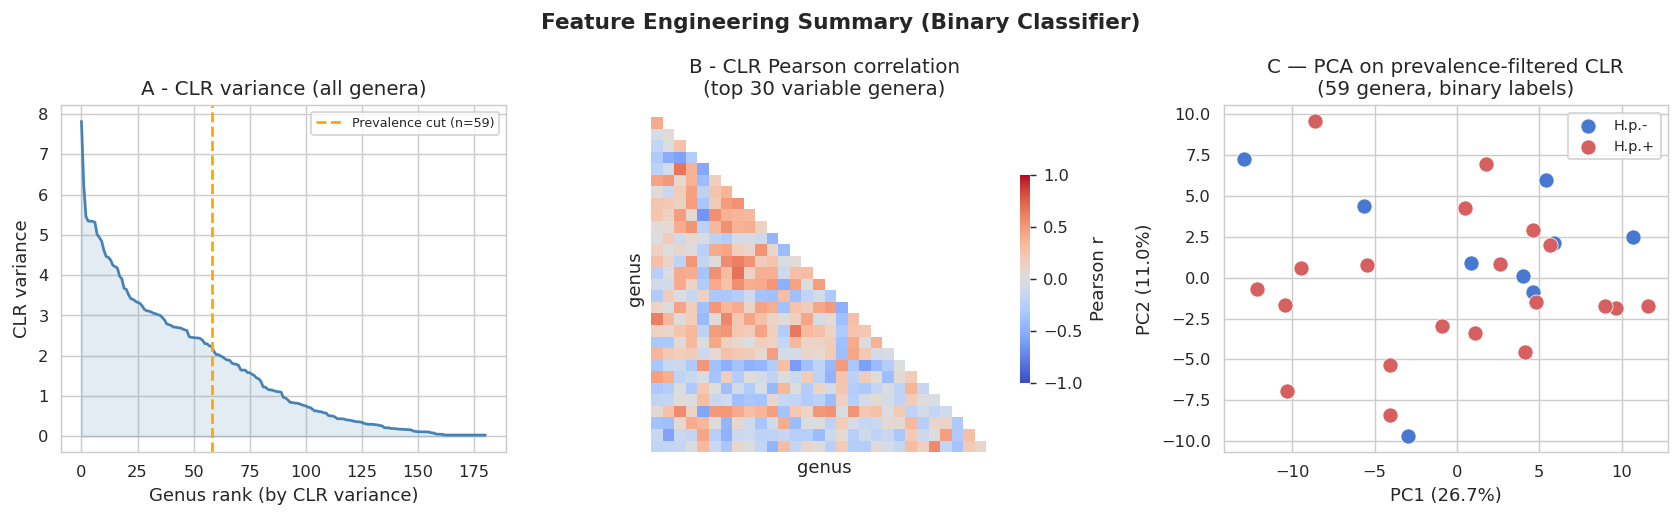

In [55]:
# Fig 13: Feature engineering summary

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Panel A - CLR variance (all genera, showing prevalence cut)
ax = axes[0]
all_var = otu_clr.var(axis=0).sort_values(ascending=False)
ax.plot(all_var.values, color='steelblue', lw=1.5)
ax.fill_between(range(len(all_var)), all_var.values, alpha=0.15, color='steelblue')
n_pass_prev = (prev_all >= MIN_PREVALENCE).sum()
ax.axvline(n_pass_prev - 1, color='orange', lw=1.5, linestyle='--',
           label=f'Prevalence cut (n={n_pass_prev})')
ax.set_xlabel('Genus rank (by CLR variance)')
ax.set_ylabel('CLR variance')
ax.set_title('A - CLR variance (all genera)')
ax.legend(fontsize=7)

# Panel B - CLR Pearson correlation (top 30 variable genera)
ax = axes[1]
top30 = otu_clr_filtered.var(axis=0).sort_values(ascending=False).head(30).index
corr  = otu_clr_filtered[top30].corr()
mask  = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True,
            xticklabels=False, yticklabels=False, ax=ax,
            cbar_kws={'shrink': 0.6, 'label': 'Pearson r'})
ax.set_title('B - CLR Pearson correlation\n(top 30 variable genera)')

# Panel C - PCA on prevalence-filtered CLR (binary colours)
ax = axes[2]
pca_fe = PCA(n_components=2, random_state=42)
X_pca2 = pca_fe.fit_transform(otu_clr_filtered.values)
for status in BINARY_ORDER:
    mask_s = y_str == status
    ax.scatter(X_pca2[mask_s, 0], X_pca2[mask_s, 1],
               c=BINARY_COLORS[status], label=status,
               s=70, edgecolors='white', lw=0.4, zorder=3)
ax.set_xlabel(f'PC1 ({pca_fe.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_fe.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'C — PCA on prevalence-filtered CLR\n'
             f'({otu_clr_filtered.shape[1]} genera, binary labels)')
ax.legend(fontsize=8)

plt.suptitle('Feature Engineering Summary (Binary Classifier)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig13_feature_engineering_binary.png', dpi=150, bbox_inches='tight')
plt.show()

In [58]:
otu.to_csv('otu_genus_raw-nhp.csv')
otu_clr.to_csv('otu_genus_clr-nhp.csv')
otu_rclr.to_csv('otu_genus_rclr-nhp.csv')
otu_clr_filtered.to_csv('otu_genus_clr_prevfiltered-nhp.csv')

meta_export = pd.DataFrame({
    'Hp_Status_binary': y_str,          # 'H.p.-' or 'H.p.+'
    'label_binary':     y_series,       # 0 or 1  <- y for the models
    'Hp_CagA_Status':   labels_3class,  # original 3-class label (for reference)
    'Score': pd.Series(scores.values, index=otu.index, name='Score'),
}, index=otu.index)
meta_export.to_csv('sample_metadata_binary-nhp.csv')

### Para el análisis de nn

**Archivos a utillizar:** `otu_genus_clr_prevfiltered.csv` + `sample_metadata.csv`

**Pipeline correcto por Walsh et al. (2024):** el variance filter, StandardScaler y
cualquier PCA deben aplicarse **dentro del loop de CV**, no antes.

**Consideraciones clave (Walsh et al. 2024; Durán et al. 2021):**
- n=29 es muy pequeño para DL. Usar **StratifiedKFold (k=5)** o **LOOCV**.
- Helicobacter domina (~56% abundancia media) y separa casi perfectamente H.p.−
  de H.p.+. Evaluar modelos **con y sin** Helicobacter para ver si el resto
  del microbioma también es informativo. ME FALTA HACER ESTA PARTE
- Los métodos **no lineales** (UMAP, etc.) capturan estructura que PCA omite
  en datos de microbioma gástrico (Durán et al. 2021).

##Referencias.


- Durán, C., Ciucci, S., Palladini, A., Ijaz, U. Z., Zippo, A. G., Paroni Sterbini, F., Masucci, L., Cammarota, G., Ianiro, G., Spuul, P., Schroeder, M., Grill, S. W., Parsons, B. N., Pritchard, D. M., Posteraro, B., Sanguinetti, M., Gasbarrini, G., Gasbarrini, A., & Cannistraci, C. V. (2021). Nonlinear machine learning pattern recognition and bacteria-metabolite multilayer network analysis of perturbed gastric microbiome. Nature Communications, 12, Article 1926. https://doi.org/10.1038/s41467-021-22135-x
- Gloor, G. B., Macklaim, J. M., Pawlowsky-Glahn, V., & Egozcue, J. J. (2017). Microbiome datasets are compositional: And this is not optional. Frontiers in Microbiology, 8, Article 2224. https://doi.org/10.3389/fmicb.2017.02224
- Greenacre, M., Martínez-Álvaro, M., & Blasco, A. (2021). Compositional data analysis of microbiome and any-omics datasets: A validation of the additive logratio transformation. Frontiers in Microbiology, 12, Article 727398. https://doi.org/10.3389/fmicb.2021.727398
- Klymiuk, I., Bilgilier, C., Stadlmann, A., Thannesberger, J., Kastner, M., Högenauer, C., Püspök, A., Biowski-Frotz, S., Schrutka-Kölbl, C., Thallinger, G. G., & Steininger, C. (2017). The Human Gastric Microbiome Is Predicated upon Infection with Helicobacter pylori. Frontiers in Microbiology, 8, 2508. https://doi.org/10.3389/fmicb.2017.02508
- Martino, C., Morton, J. T., Marotz, C. A., Thompson, L. R., Tripathi, A., Knight, R., & Zengler, K. (2019). A novel sparse compositional technique reveals microbial perturbations. mSystems, 4(1), Article e00016-19. https://doi.org/10.1128/mSystems.00016-19
- Walsh, C., Stallard-Olivera, E., & Fierer, N. (2024). Nine (not so simple) steps: A practical guide to using machine learning in microbial ecology. mBio, 15(2), Article e02050-23. https://doi.org/10.1128/mbio.02050-23